# Data Setup

In [67]:
# === 1. IMPORT LIBRARIES ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import re
import plotly.graph_objects as go
from dateutil.parser import parse
from IPython.display import display
import dash
from dash import dcc, html, Input, Output, State
import os

# Data Cleaning

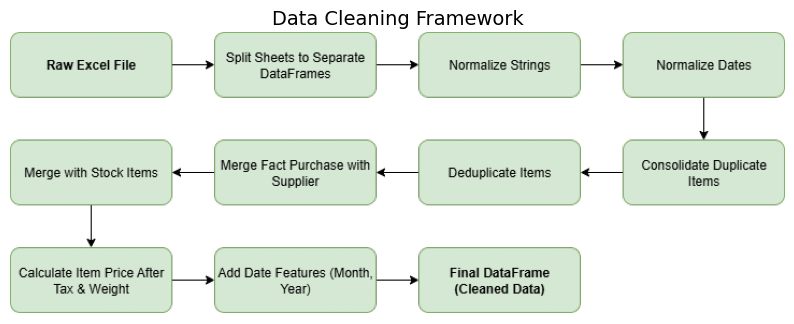

In [68]:
# === Load Image from /media/ Directory ===
image_path = os.path.join('media', 'data cleaning framework.png')

# Read the image
img = mpimg.imread(image_path)

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.title("Data Cleaning Framework", fontsize=14)
plt.show()


## Data Cleaning Process

In [13]:
# === 2. LOAD RAW DATA FROM EXCEL ===
file_path = './data/raw/Procurement_Data.xlsx'
excel_file = pd.ExcelFile(file_path)

# Create individual dataframes
sheets_dict = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in excel_file.sheet_names}

# Assign each sheet to a standalone variable with cleaned name
for sheet_name, df in sheets_dict.items():
    # Clean the sheet name to create a valid variable name
    var_name = sheet_name.lower().strip().replace(' ', '_').replace('-', '_')
    globals()[f'df_{var_name}'] = df

# Declare variable names
print("DataFrames created:")
for sheet_name in sheets_dict:
    var_name = sheet_name.lower().strip().replace(' ', '_').replace('-', '_')
    print(f"df_{var_name}")
    df_fact_purchase.info()
df_dim_supplier.info()
df_dim_stock_item.info()

# Insert relevant sheets into separate dataframe
df_fact_purchase_raw = sheets_dict['Fact Purchase']
df_dim_supplier_raw = sheets_dict['Dim Supplier']
df_dim_stock_item_raw = sheets_dict['Dim Stock Item']

DataFrames created:
df_instructions
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8367 entries, 0 to 8366
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Purchase Key           8367 non-null   int64 
 1   Date Key               8367 non-null   object
 2   Supplier Key           8367 non-null   int64 
 3   Stock Item Key         8367 non-null   int64 
 4   WWI Purchase Order ID  8367 non-null   int64 
 5   Ordered Outers         8367 non-null   int64 
 6   Ordered Quantity       8367 non-null   int64 
 7   Received Outers        8367 non-null   int64 
 8   Package                8367 non-null   object
 9   Is Order Finalized     8367 non-null   bool  
 10  Lineage Key            8367 non-null   int64 
dtypes: bool(1), int64(8), object(2)
memory usage: 662.0+ KB
df_dim_stock_item
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8367 entries, 0 to 8366
Data columns (total 11 columns):
 #   Col

# Data Cleaning

In [14]:
# date normalization
def normalize_string(value):
    if pd.isnull(value):
        return value
    value = str(value)
    value = re.sub(r'\s+', '', value)  # Remove all whitespace inside string (e.g. "E A C H" -> "EACH")
    return value.strip().title()


# Helper: Parse and normalize date columns
def normalize_dates(df):
    def safe_parse_date(x):
        try:
            if pd.isnull(x) or str(x).strip() == '':
                return pd.NaT

            x = str(x).strip()

            # Fix known malformed values
            if x == 'February29,2016':
                x = 'February 29, 2016'
            if x == '9999-12-3123:59:59.996000':
                x = '9999-12-31 23:59:59.996000'

            return parse(x)
        except Exception:
            return pd.NaT

    for col in df.columns:
        if 'date' in col.lower() or 'valid from' in col.lower() or 'valid to' in col.lower():
            try:
                df[col] = df[col].apply(safe_parse_date)
            except Exception as e:
                print(f"Could not parse dates in column: {col} — {e}")
    return df

df_fact_purchase = normalize_dates(df_fact_purchase)
df_dim_supplier = normalize_dates(df_dim_supplier)
df_dim_stock_item = normalize_dates(df_dim_stock_item)

In [15]:
# === 4.1 CLEAN FACT PURCHASE ===
df_fact_purchase_clean = df_fact_purchase_raw.copy()

# Normalize 'Package' column
df_fact_purchase_clean['Package'] = df_fact_purchase_clean['Package'].apply(normalize_string)

# Normalize dates (purchase_date)
df_fact_purchase_clean = normalize_dates(df_fact_purchase_clean)

# Rename standardized date column for clarity
df_fact_purchase_clean['purchase_date'] = df_fact_purchase_clean['Date Key']

# ==========================
# === 4.2 CLEAN SUPPLIER ===
df_dim_supplier = df_dim_supplier_raw.copy()

# Normalize all date columns
df_dim_supplier = normalize_dates(df_dim_supplier)

# Remove duplicate suppliers
dupes = df_dim_supplier[df_dim_supplier.duplicated(subset='Supplier', keep=False)].copy()

latest = dupes.sort_values('Valid From', ascending=False).groupby('Supplier').head(1)
remaining = latest[latest.duplicated(subset='Supplier', keep=False)]
final = remaining.sort_values('Supplier Key', ascending=False).groupby('Supplier').head(1)

unique = df_dim_supplier[~df_dim_supplier['Supplier'].isin(dupes['Supplier'])]
df_dim_supplier_clean = pd.concat([unique, latest[~latest['Supplier'].isin(final['Supplier'])], final], ignore_index=True)

# ==========================
# === 4.3 CLEAN STOCK ITEM ===
df_dim_stock_item = df_dim_stock_item_raw.copy()

# Normalize package strings
df_dim_stock_item['Selling Package'] = df_dim_stock_item['Selling Package'].apply(normalize_string)
df_dim_stock_item['Buying Package'] = df_dim_stock_item['Buying Package'].apply(normalize_string)

# Normalize all relevant date columns
df_dim_stock_item = normalize_dates(df_dim_stock_item)

# Remove exact duplicates
df_dim_stock_item = df_dim_stock_item.drop_duplicates()

# ==========================
# === 4.4 CONSOLIDATE MULTI-VERSION STOCK ITEMS ===
df_sorted = df_dim_stock_item.sort_values(by=['Stock Item', 'Valid From', 'WWI Stock Item ID'])
df_deduped = df_sorted.drop_duplicates(subset=['Stock Item', 'Valid From'], keep='first')

# Identify items appearing twice (versioned)
counts = df_deduped['Stock Item'].value_counts()
twice = counts[counts == 2].index
df_twice = df_deduped[df_deduped['Stock Item'].isin(twice)].copy()

# Consolidate by expanding Valid To of older record
max_idx = df_twice.groupby('Stock Item')['Stock Item Key'].idxmax()
min_idx = df_twice.groupby('Stock Item')['Stock Item Key'].idxmin()

df_deduped.loc[min_idx, 'Valid To'] = df_deduped.loc[max_idx, 'Valid From']
df_dim_stock_item_clean = df_deduped.drop(index=max_idx).reset_index(drop=True)


# Data Transformation

In [16]:
# === 5. DATA TRANSFORMATION ===
# Add price after tax
df_dim_stock_item_clean['Price After Tax'] = df_dim_stock_item_clean['Unit Price'] * (1 + df_dim_stock_item_clean['Tax Rate'] / 100)

# Merge all together
merged_df = df_fact_purchase_clean.merge(
    df_dim_supplier_clean[['Supplier Key', 'Supplier']], on='Supplier Key', how='inner'
)
merged_df = merged_df.merge(
    df_dim_stock_item_clean[['Stock Item Key', 'Stock Item', 'Price After Tax', 'Typical Weight Per Unit']],
    on='Stock Item Key', how='inner'
)

# Calculate metrics
merged_df['Total Price'] = merged_df['Price After Tax'] * merged_df['Ordered Quantity']
merged_df['Total Weight'] = merged_df['Typical Weight Per Unit'] * merged_df['Ordered Quantity']


In [17]:
# Create the final dataframe with a deep copy
final_df = merged_df[[
    'Purchase Key', 'Date Key', 'Supplier', 'Stock Item',
    'Ordered Quantity', 'Received Outers',
    'Price After Tax', 'Total Price',
    'Typical Weight Per Unit', 'Total Weight'
]].copy()

# Add date features
final_df['Year'] = pd.to_datetime(final_df['Date Key']).dt.year
final_df['Month'] = pd.to_datetime(final_df['Date Key']).dt.to_period('M').dt.to_timestamp()
final_df.head()

,Purchase Key,Date Key,Supplier,Stock Item,Ordered Quantity,Received Outers,Price After Tax,Total Price,Typical Weight Per Unit,Total Weight,Year,Month
0,5,2013-01-01,"Fabrikam, Inc.","""The Gu"" red shirt XML tag t-shirt (White) XXS",12,1,19.26,231.12,0.25,3.0,2013,2013-01-01
1,95,2013-02-01,"Fabrikam, Inc.","""The Gu"" red shirt XML tag t-shirt (White) XXS",72,6,19.26,1386.72,0.25,18.0,2013,2013-02-01
2,140,2013-01-03,"Fabrikam, Inc.","""The Gu"" red shirt XML tag t-shirt (White) XXS",132,11,19.26,2542.32,0.25,33.0,2013,2013-01-01
3,172,2013-04-01,"Fabrikam, Inc.","""The Gu"" red shirt XML tag t-shirt (White) XXS",108,9,19.26,2080.08,0.25,27.0,2013,2013-04-01
4,187,2013-05-01,"Fabrikam, Inc.","""The Gu"" red shirt XML tag t-shirt (White) XXS",24,2,19.26,462.24,0.25,6.0,2013,2013-05-01


# EXPLORATORY DATA ANALYSIS

In [18]:
# === 6. EDA: DISTINCT PRODUCTS PER YEAR ===
distinct_items = final_df.groupby('Year')['Stock Item'].nunique().reset_index(name='Distinct Product Count')
display(distinct_items)

,Year,Distinct Product Count
0,2013,219
1,2014,9
2,2015,9
3,2016,17


In [19]:
# === 6. EDA: SUPPLIER TRANSACTION SUMMARY ===
summary = final_df.groupby(['Supplier', 'Year']).agg(
    Total_Spent=('Total Price', 'sum'),
    Ordered_Outers=('Received Outers', 'sum'),
    Unique_Items=('Stock Item', 'nunique'),
    Transactions=('Purchase Key', 'count')
).reset_index()

display(summary)


,Supplier,Year,Total_Spent,Ordered_Outers,Unique_Items,Transactions
0,A Datum Corporation,2016,4.609909e+04,221,8,10
1,"Contoso, Ltd.",2013,9.302400e+02,57,3,3
2,"Fabrikam, Inc.",2013,1.370989e+08,593797,74,1705
3,"Fabrikam, Inc.",2014,4.328029e+08,1872633,6,1695
4,"Fabrikam, Inc.",2015,7.628756e+08,3300777,6,1694
5,"Fabrikam, Inc.",2016,4.226230e+08,1810376,6,708
6,Graphic Design Institute,2013,2.099552e+04,1442,42,42
7,"Litware, Inc.",2013,2.007295e+07,82494,67,556
8,"Litware, Inc.",2014,1.341197e+08,550607,3,734
9,"Litware, Inc.",2015,2.923857e+08,1309350,3,845


In [20]:
# === TRANSACTION SUMMARY (2013–2016) ===
summary_stats = {
    'Total Transactions': final_df['Purchase Key'].nunique(),
    'Total Spent (After Tax)': final_df['Total Price'].sum(),
    'Total Quantity': final_df['Ordered Quantity'].sum(),
    'Unique Items': final_df['Stock Item'].nunique(),
    'Suppliers': final_df['Supplier'].nunique()
}
summary_stats


{'Total Transactions': 8367,
 'Total Spent (After Tax)': 2370305378.7400002,
 'Total Quantity': 139778604,
 'Unique Items': 227,
 'Suppliers': 7}

In [21]:
# === MOST PROCURED ITEMS BY QUANTITY ===
top_items = final_df.groupby('Stock Item').agg(
    Total_Quantity=('Ordered Quantity', 'sum'),
    Total_Spend=('Total Price', 'sum'),
    Days_Purchased=('Date Key', 'nunique')
).sort_values(by='Total_Quantity', ascending=False).reset_index()

display(top_items.head(10))

,Stock Item,Total_Quantity,Total_Spend,Days_Purchased
0,Black and orange glass with care despatch tape...,25136184,1.060244e+08,843
1,"""The Gu"" red shirt XML tag t-shirt (Black) 4XL",18905436,3.641187e+08,903
2,"""The Gu"" red shirt XML tag t-shirt (White) XS",18753348,3.611895e+08,903
3,"""The Gu"" red shirt XML tag t-shirt (White) 5XL",18146820,3.495078e+08,892
4,"""The Gu"" red shirt XML tag t-shirt (White) XXS",17402364,3.351695e+08,901
5,Tape dispenser (Red),12048250,4.626528e+08,885
6,Shipping carton (Brown) 305x305x305mm,11431625,4.561218e+07,545
7,"""The Gu"" red shirt XML tag t-shirt (Black) XL",9269184,1.785245e+08,916
8,"""The Gu"" red shirt XML tag t-shirt (White) M",8659884,1.667894e+08,879
9,Black and yellow heavy despatch tape 48mmx75m,1320,5.567760e+03,9


In [22]:
# === MONTHLY SPENDING BY ITEM (IDENTIFY OUTLIERS) ===
monthly_item_spending = final_df.groupby(['Month', 'Stock Item']).agg(
    Monthly_Spend=('Total Price', 'sum'),
    Monthly_Quantity=('Ordered Quantity', 'sum')
).reset_index()

# Filter top spending items in May 2016
may2016_items = monthly_item_spending[
    (monthly_item_spending['Month'] == '2016-05-01') |
    (monthly_item_spending['Month'] == pd.to_datetime('2016-05-01'))
].sort_values(by='Monthly_Spend', ascending=False)

display(may2016_items.head(10))

,Month,Stock Item,Monthly_Spend,Monthly_Quantity
583,2016-05-01,Tape dispenser (Red),2.455795e+07,639530
574,2016-05-01,"""The Gu"" red shirt XML tag t-shirt (Black) 4XL",1.856887e+07,964116
578,2016-05-01,"""The Gu"" red shirt XML tag t-shirt (White) XS",1.761273e+07,914472
576,2016-05-01,"""The Gu"" red shirt XML tag t-shirt (White) 5XL",1.704048e+07,884760
579,2016-05-01,"""The Gu"" red shirt XML tag t-shirt (White) XXS",1.531193e+07,795012
577,2016-05-01,"""The Gu"" red shirt XML tag t-shirt (White) M",9.070998e+06,470976
575,2016-05-01,"""The Gu"" red shirt XML tag t-shirt (Black) XL",8.215160e+06,426540
580,2016-05-01,Black and orange glass with care despatch tape...,5.570493e+06,1320648
582,2016-05-01,Shipping carton (Brown) 305x305x305mm,3.064719e+06,768100
581,2016-05-01,Chocolate frogs 250g,2.958984e+03,336


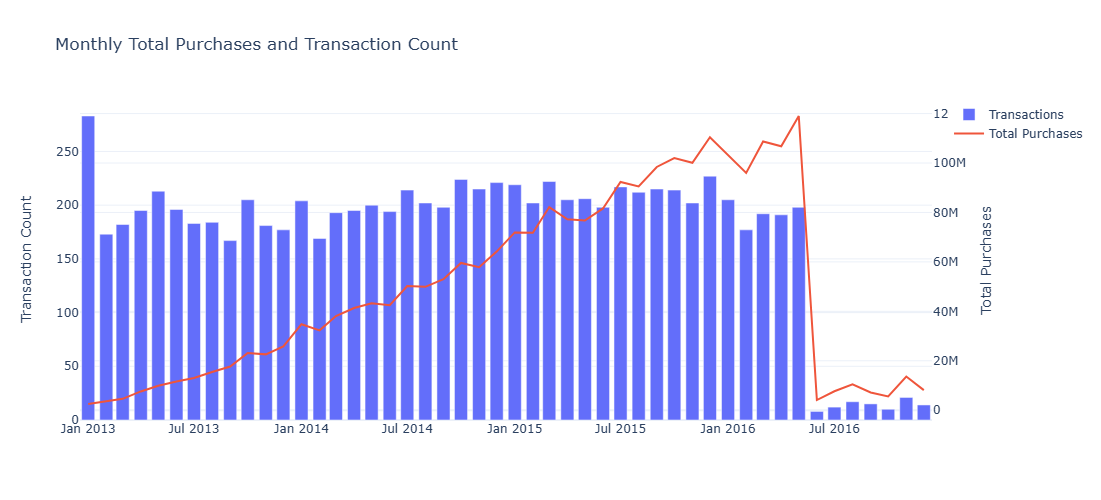

In [23]:
# Shows instability in purchasing patterns

monthly_summary = final_df.groupby('Month').agg(
    Total_Purchases=('Total Price', 'sum'),
    Transaction_Count=('Purchase Key', 'count')
).reset_index()

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Bar(
    x=np.array(monthly_summary['Month']), 
    y=monthly_summary['Transaction_Count'], 
    name='Transactions'
))
fig.add_trace(go.Scatter(
    x=np.array(monthly_summary['Month']), 
    y=monthly_summary['Total_Purchases'], 
    name='Total Purchases', 
    yaxis='y2'
))
fig.update_layout(
    title='Monthly Total Purchases and Transaction Count',
    yaxis=dict(title='Transaction Count'),
    yaxis2=dict(title='Total Purchases', overlaying='y', side='right'),
    template='plotly_white',
    height=500
)
fig.show()

In [25]:
# === TOTAL SPEND BY SUPPLIER===
spend_by_supplier = final_df.groupby('Supplier')['Total Price'].sum().sort_values(ascending=False).reset_index()

# Format numbers with thousands separators
spend_by_supplier['Total Price'] = spend_by_supplier['Total Price'].apply(lambda x: f"{x:,.0f}")

# Display as styled table
display(spend_by_supplier.style.set_caption("Total Procurement Spend by Supplier").set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
]).set_properties(**{
    'text-align': 'right'
}))


,Supplier,Total Price
0,"Fabrikam, Inc.","1,755,400,426"
1,"Litware, Inc.","614,528,281"
2,Northwind Electric Cars,"154,362"
3,The Phone Company,"154,285"
4,A Datum Corporation,"46,099"
5,Graphic Design Institute,"20,996"
6,"Contoso, Ltd.",930


In [26]:
# === TOTAL QUANTITY ORDERED BY SUPPLIER ===
quantity_by_supplier = final_df.groupby('Supplier')['Ordered Quantity'].sum().sort_values(ascending=False).reset_index()

# Format quantity with thousands separators
quantity_by_supplier['Ordered Quantity'] = quantity_by_supplier['Ordered Quantity'].apply(lambda x: f"{x:,.0f}")

# Display as styled table
display(quantity_by_supplier.style.set_caption("Total Ordered Quantity by Supplier").set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
]).set_properties(**{
    'text-align': 'right'
}))


,Supplier,Ordered Quantity
0,"Fabrikam, Inc.","91,142,279"
1,"Litware, Inc.","48,626,764"
2,A Datum Corporation,"5,076"
3,The Phone Company,"1,730"
4,Graphic Design Institute,"1,442"
5,Northwind Electric Cars,"1,256"
6,"Contoso, Ltd.",57


In [27]:
# === FREQUENCY OF 'THE GU' ITEMS ===
the_gu_items = final_df[final_df['Stock Item'].str.contains('The Gu', case=False)]
gu_summary = the_gu_items.groupby('Stock Item').agg(
    Total_Quantity=('Ordered Quantity', 'sum'),
    Days_Procured=('Date Key', 'nunique')
).sort_values(by='Total_Quantity', ascending=False)

display(gu_summary)


,Total_Quantity,Days_Procured
Stock Item,,
"""The Gu"" red shirt XML tag t-shirt (Black) 4XL",18905436,903
"""The Gu"" red shirt XML tag t-shirt (White) XS",18753348,903
"""The Gu"" red shirt XML tag t-shirt (White) 5XL",18146820,892
"""The Gu"" red shirt XML tag t-shirt (White) XXS",17402364,901
"""The Gu"" red shirt XML tag t-shirt (Black) XL",9269184,916
"""The Gu"" red shirt XML tag t-shirt (White) M",8659884,879
"""The Gu"" red shirt XML tag t-shirt (Black) 3XL",288,1
"""The Gu"" red shirt XML tag t-shirt (Black) XXL",228,1
"""The Gu"" red shirt XML tag t-shirt (White) XXL",216,2


In [28]:
# === DETECT DOUBLE ORDERS (SAME DAY, SAME ITEM) ===
duplicate_orders = final_df.groupby(['Date Key', 'Stock Item']).size().reset_index(name='Order Count')
double_orders = duplicate_orders[duplicate_orders['Order Count'] > 1]
print("Number of double orders:")
len(double_orders.sort_values('Order Count', ascending=False))

Number of double orders:


463

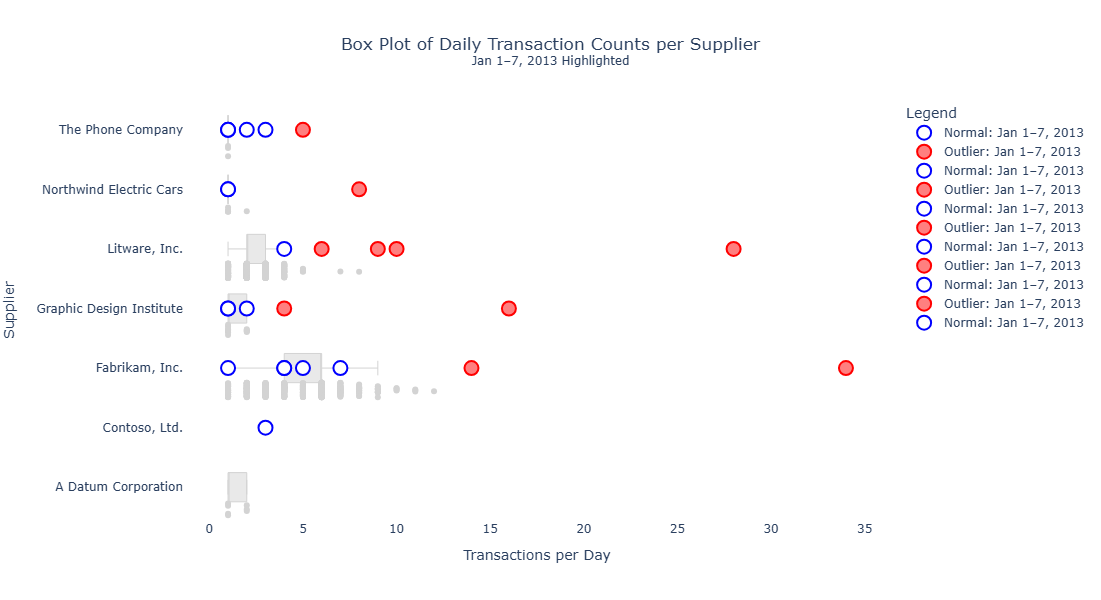

In [29]:
# DETECT OUTLIERS
# === STEP 1: PREPARE DAILY TRANSACTION COUNTS ===
df = final_df.copy()
df['Date'] = pd.to_datetime(df['Date Key']).dt.date  # Ensure proper date extraction

# Count transactions per supplier per day
daily_tx = df.groupby(['Supplier', 'Date']).size().reset_index(name='Transaction Count')

# === STEP 2: DETECT OUTLIERS USING IQR METHOD ===
outlier_rows = []
for supplier, group in daily_tx.groupby('Supplier'):
    q1 = group['Transaction Count'].quantile(0.25)
    q3 = group['Transaction Count'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = group[(group['Transaction Count'] < lower) | (group['Transaction Count'] > upper)].copy()
    outliers['Outlier'] = True
    outlier_rows.append(outliers)

outlier_df = pd.concat(outlier_rows) if outlier_rows else pd.DataFrame(columns=daily_tx.columns.tolist() + ['Outlier'])

# === STEP 3: COMBINE OUTLIERS FLAG ===
daily_tx['Outlier'] = False
if not outlier_df.empty:
    outlier_index = outlier_df.set_index(['Supplier', 'Date']).index
    daily_tx.loc[daily_tx.set_index(['Supplier', 'Date']).index.isin(outlier_index), 'Outlier'] = True

# === STEP 4: DEFINE HIGHLIGHT DATE RANGE ===
highlight_start = pd.to_datetime("2013-01-01").date()
highlight_end = pd.to_datetime("2013-01-07").date()
daily_tx['Highlight'] = daily_tx['Date'].between(highlight_start, highlight_end)

# === STEP 5: PLOT WITH PLOTLY ===
fig = go.Figure()

for supplier, group in daily_tx.groupby("Supplier"):
    base = group[~group["Highlight"]]
    highlight_outliers = group[(group["Highlight"]) & (group["Outlier"])]
    highlight_normals = group[(group["Highlight"]) & (~group["Outlier"])]

    # Base boxplot with all daily counts
    fig.add_trace(go.Box(
        x=base["Transaction Count"],
        y=[supplier] * len(base),
        boxpoints='all',
        jitter=0.5,
        marker=dict(size=6, color='lightgray'),
        line=dict(width=1),
        orientation='h',
        name=supplier,
        hovertext=base["Date"].astype(str),
        showlegend=False
    ))

    # Highlighted red outliers (Jan 1–7, 2013)
    if not highlight_outliers.empty:
        fig.add_trace(go.Scatter(
            x=highlight_outliers["Transaction Count"],
            y=[supplier] * len(highlight_outliers),
            mode='markers',
            marker=dict(size=14, color='rgba(255,0,0,0.5)', line=dict(color='red', width=2), symbol='circle'),
            name='Outlier: Jan 1–7, 2013',
            hovertext=highlight_outliers["Date"].astype(str),
            showlegend=True
        ))

    # Highlighted blue normals (Jan 1–7, 2013)
    if not highlight_normals.empty:
        fig.add_trace(go.Scatter(
            x=highlight_normals["Transaction Count"],
            y=[supplier] * len(highlight_normals),
            mode='markers',
            marker=dict(size=14, color='white', line=dict(color='blue', width=2), symbol='circle'),
            name='Normal: Jan 1–7, 2013',
            hovertext=highlight_normals["Date"].astype(str),
            showlegend=True
        ))

# === FINALIZE LAYOUT ===
fig.update_layout(
    title="Box Plot of Daily Transaction Counts per Supplier<br><sup>Jan 1–7, 2013 Highlighted</sup>",
    xaxis_title="Transactions per Day",
    yaxis_title="Supplier",
    template="plotly_white",
    title_x=0.5,
    height=600,
    legend_title_text='Legend'
)

fig.show()


In [30]:
## 5.2. Identify unique items sold each year

In [31]:
# === DISTINCT ITEMS PURCHASED EACH YEAR (2013–2016) ===
distinct_items_yearly = (
    final_df[final_df['Year'].between(2013, 2016)]
    .groupby('Year')['Stock Item']
    .nunique()
    .reset_index(name='Distinct Items Purchased')
)

# Format numbers with commas
distinct_items_yearly['Distinct Items Purchased'] = distinct_items_yearly['Distinct Items Purchased'].apply(lambda x: f"{x:,}")

# Display as styled table
display(distinct_items_yearly.style.set_caption("Number of Distinct Items Purchased Per Year").set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
]).set_properties(**{
    'text-align': 'right'
}))


,Year,Distinct Items Purchased
0,2013,219
1,2014,9
2,2015,9
3,2016,17


In [32]:
## Items that aren't procured in 2013
# Get unique items by year
items_2013 = set(final_df[final_df['Date Key'].dt.year == 2013]['Stock Item'].unique())
items_other_years = set(final_df[final_df['Date Key'].dt.year.isin([2014, 2015, 2016])]['Stock Item'].unique())

# Items not in 2013
new_items = sorted(items_other_years - items_2013)

print(new_items)


['Chocolate beetles 250g', 'Chocolate echidnas 250g', 'Chocolate frogs 250g', 'Chocolate sharks 250g', 'Novelty chilli chocolates 250g', 'Novelty chilli chocolates 500g', 'White chocolate moon rocks 250g', 'White chocolate snow balls 250g']


In [26]:
## 5.4. See suppliers that haven't been used
# Step 1: Exclude suppliers with Lineage Key = 0
df_dim_supplier_clean = df_dim_supplier_clean[df_dim_supplier_clean['Lineage Key'] != 0]

# Step 2: Get suppliers not in df_final
unused_suppliers = df_dim_supplier_clean[~df_dim_supplier_clean['Supplier'].isin(final_df['Supplier'])]

# Step 3: Get used suppliers with category and payment days
used_suppliers = df_dim_supplier_clean[
    df_dim_supplier_clean['Supplier'].isin(final_df['Supplier'])
][['Supplier', 'Category', 'Payment Days']]

# Step 4: Merge each unused supplier with matching category from used suppliers
result_rows = []
for _, row in unused_suppliers.iterrows():
    category = row['Category']
    match = used_suppliers[used_suppliers['Category'] == category]
    
    for _, match_row in match.iterrows():
        result_rows.append({
            'Supplier not in df_final': row['Supplier'],
            'Category': category,
            'Common Supplier (Same Category)': match_row['Supplier'],
            'Payment Days': row['Payment Days'],
            'Compared To': match_row['Payment Days'],
            'Payment Days Compared': row['Payment Days'] - match_row['Payment Days']
        })

# Step 5: Create result DataFrame
result_df = pd.DataFrame(result_rows)

result_df


,Supplier not in df_final,Category,Common Supplier (Same Category),Payment Days,Compared To,Payment Days Compared
0,Nod Publishers,Novelty Goods Supplier,A Datum Corporation,7,14,-7
1,Nod Publishers,Novelty Goods Supplier,"Contoso, Ltd.",7,7,0
2,Nod Publishers,Novelty Goods Supplier,The Phone Company,7,30,-23
3,Nod Publishers,Novelty Goods Supplier,Graphic Design Institute,7,14,-7
4,Lucerne Publishing,Novelty Goods Supplier,A Datum Corporation,30,14,16
5,Lucerne Publishing,Novelty Goods Supplier,"Contoso, Ltd.",30,7,23
6,Lucerne Publishing,Novelty Goods Supplier,The Phone Company,30,30,0
7,Lucerne Publishing,Novelty Goods Supplier,Graphic Design Institute,30,14,16


In [27]:
# === SUPPLIER ENGAGEMENT SUMMARY BY CATEGORY ===

# Ensure clean supplier names
df_dim_supplier_clean['Supplier'] = df_dim_supplier_clean['Supplier'].str.strip()

# Get list of involved supplier names
involved_suppliers = final_df['Supplier'].unique()

# Group suppliers by Category
category_groups = df_dim_supplier_clean.groupby('Category')

summary_rows = []

for category, group in category_groups:
    all_suppliers = group['Supplier'].sort_values().tolist()
    involved = sorted([s for s in all_suppliers if s in involved_suppliers])
    not_involved = sorted([s for s in all_suppliers if s not in involved_suppliers])

    summary_rows.append({
        'Category': category,
        'Total Suppliers': len(all_suppliers),
        'Suppliers Involved': len(involved),
        'List of Involved Suppliers': ", ".join(involved)  if involved else "-",
        'List of Non-Involved Suppliers': ", ".join(not_involved) if not_involved else "-"
    })

supplier_summary_df = pd.DataFrame(summary_rows)

# Display table
display(supplier_summary_df.style.set_caption("Supplier Engagement by Category").set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
]).set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap'
}))


,Category,Total Suppliers,Suppliers Involved,List of Involved Suppliers,List of Non-Involved Suppliers
0,Clothing Supplier,1,1,"Fabrikam, Inc.",-
1,Courier,1,0,-,Consolidated Messenger
2,Financial Services Supplier,1,0,-,Woodgrove Bank
3,Insurance Services Supplier,1,0,-,Humongous Insurance
4,Marketing Services Supplier,1,0,-,Trey Research
5,Novelty Goods Supplier,6,4,"A Datum Corporation, Contoso, Ltd., Graphic Design Institute, The Phone Company","Lucerne Publishing, Nod Publishers"
6,Packaging Supplier,1,1,"Litware, Inc.",-
7,Toy Supplier,1,1,Northwind Electric Cars,-


In [ ]:
## Purchases by year

In [28]:
summary = (
    final_df
    .groupby(final_df['Date Key'].dt.year)
    .agg(
        total_quantity=('Ordered Quantity', 'sum'),
        total_purchase=('Total Price', 'sum')
    )
    .reset_index()
    .rename(columns={'Date Key': 'Year'})
)

print(summary)


   Year  total_quantity  total_purchase
0  2013         8523392    1.575024e+08
1  2014        31845160    5.669226e+08
2  2015        63350515    1.055261e+09
3  2016        36059537    5.906190e+08


In [30]:
## Purchases by month
final_df['YearMonth'] = final_df['Date Key'].dt.to_period('M')

monthly_summary = final_df.groupby('YearMonth').agg(
    total_purchases=('Total Price', 'sum'),
    total_quantity=('Ordered Quantity', 'sum'),
    transaction_count=('Total Price', 'count')
).reset_index()

# Convert YearMonth back to datetime for plotting if needed
monthly_summary['YearMonth'] = monthly_summary['YearMonth'].dt.to_timestamp()

monthly_summary

,YearMonth,total_purchases,total_quantity,transaction_count
0,2013-01-01,2.506955e+06,120501,283
1,2013-02-01,3.646956e+06,195904,173
2,2013-03-01,4.584984e+06,243073,182
3,2013-04-01,7.593417e+06,412943,195
4,2013-05-01,9.883192e+06,559051,213
5,2013-06-01,1.159546e+07,633992,196
6,2013-07-01,1.305186e+07,701903,183
7,2013-08-01,1.543569e+07,832380,184
8,2013-09-01,1.765639e+07,950132,167
9,2013-10-01,2.311580e+07,1237838,205


In [ ]:
# 6. Data Visualization

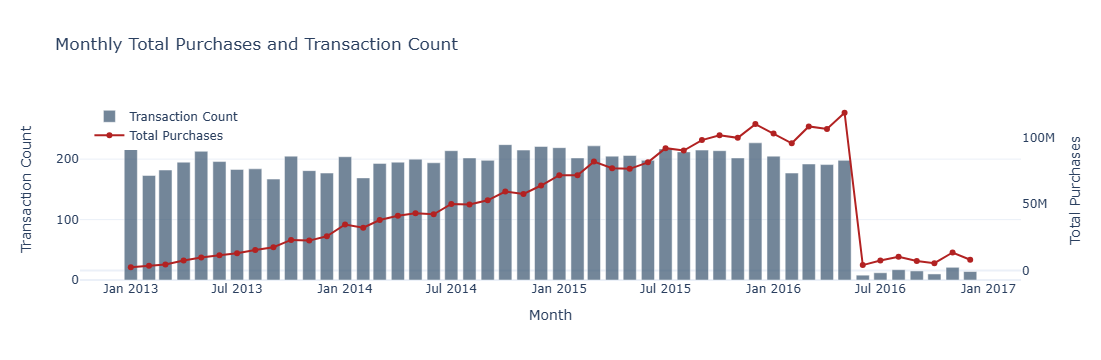

In [32]:
import numpy as np
import plotly.graph_objects as go

# Create figure with secondary y-axis
fig = go.Figure()

# Bar chart for transaction count
fig.add_trace(go.Bar(
    x=np.array(monthly_summary['YearMonth']),
    y=monthly_summary['transaction_count'],
    name='Transaction Count',
    marker_color='rgba(55, 83, 109, 0.7)',
    yaxis='y1'
))

# Line chart for total purchases
fig.add_trace(go.Scatter(
    x=np.array(monthly_summary['YearMonth']),
    y=monthly_summary['total_purchases'].astype(float),
    name='Total Purchases',
    mode='lines+markers',
    line=dict(color='firebrick', width=2),
    yaxis='y2'
))

# Layout with dual axes
fig.update_layout(
    title='Monthly Total Purchases and Transaction Count',
    xaxis=dict(title='Month'),
    yaxis=dict(
        title='Transaction Count',
        side='left'
    ),
    yaxis2=dict(
        title='Total Purchases',
        overlaying='y',
        side='right',
        showgrid=False
    ),
    legend=dict(x=0.01, y=0.99),
    template='plotly_white',
    height=500
)

fig.show()


C:\Users\FarrelMahardhikaFaja\AppData\Local\Temp\ipykernel_25488\3922958303.py:10: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



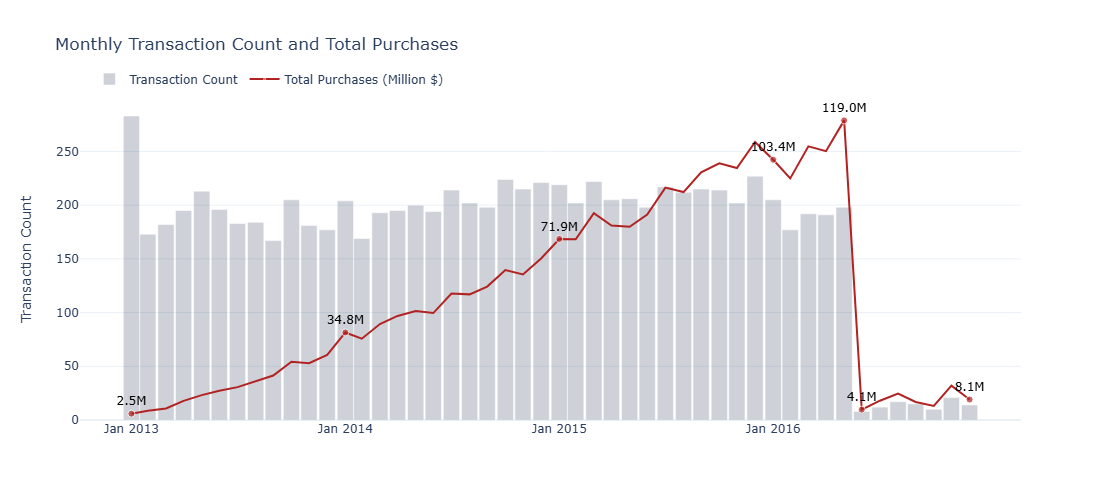

In [48]:
#==DISPLAY MONTHLY TRANSACTIO AND GLOBAL PURCHASES==#

# === Data Preparation ===
df = final_df.copy()
df['Date'] = pd.to_datetime(df['Date Key'])

# Monthly Aggregation
monthly_summary = (
    df.groupby(pd.Grouper(key='Date', freq='M'))
      .agg({
          'Purchase Key': 'nunique',  # Transaction Count
          'Total Price': 'sum'
      })
      .reset_index()
      .rename(columns={'Purchase Key': 'Transaction Count'})
)

# Key months: Januarys, Final, Max, After Max
final_month = monthly_summary['Date'].max()
max_purchase_month = monthly_summary.loc[monthly_summary['Total Price'].idxmax(), 'Date']
after_max_purchase_month = max_purchase_month + pd.DateOffset(months=1)

# Add flags for labeling & dot display
monthly_summary['Show_Label'] = monthly_summary['Date'].apply(
    lambda d: d.month == 1 or d == final_month or d == max_purchase_month or d == after_max_purchase_month
)

# X-axis labels: Only Januarys
monthly_summary['X_Label'] = monthly_summary['Date'].apply(
    lambda d: d.strftime('%b\n%Y') if d.month == 1 else ''
)

# === Plotly Chart ===
fig = go.Figure()

# --- Bar Chart: Transaction Count (20% opacity) ---
fig.add_trace(go.Bar(
    x=monthly_summary['Date'],
    y=monthly_summary['Transaction Count'],
    name='Transaction Count',
    marker_color='rgba(10, 30, 60, 0.2)',  # Dark blue with 20% opacity
    yaxis='y1',
    hovertemplate='Transactions: %{y:,}<extra></extra>'
))

# --- Line Chart: Total Purchases (in Millions) ---
marker_sizes = [7 if flag else 0 for flag in monthly_summary['Show_Label']]

# Scale Total Price to Millions
monthly_summary['Total Price (M)'] = monthly_summary['Total Price'] / 1e6

# Add Line trace
fig.add_trace(go.Scatter(
    x=monthly_summary['Date'],
    y=monthly_summary['Total Price (M)'],
    mode='lines+markers+text',
    name='Total Purchases (Million $)',
    line=dict(color='firebrick', width=2),
    marker=dict(size=marker_sizes, color='firebrick'),
    text=[f"{v:.1f}M" if flag else '' for v, flag in zip(monthly_summary['Total Price (M)'], monthly_summary['Show_Label'])],
    textposition='top center',
    textfont=dict(size=12, color='black'),
    texttemplate="<span style='background-color:rgba(255,255,255,0.5);padding:2px'>%{text}</span>",
    yaxis='y2',
    hovertemplate='Total Purchases: $%{y:,.1f}M<extra></extra>'
))

# === Layout Settings ===
fig.update_layout(
    title='Monthly Transaction Count and Total Purchases',
    template='plotly_white',
    height=500,
    xaxis=dict(
        title='',
        tickmode='array',
        tickvals=monthly_summary['Date'],
        ticktext=monthly_summary['X_Label'],
        showgrid=False
    ),
    yaxis=dict(
        title='Transaction Count',
        tickformat=',',  # Thousands separator
        showline=False,
        showgrid=True,   # Horizontal helper lines
        rangemode='tozero'
    ),
    yaxis2=dict(
        overlaying='y',
        side='right',
        showticklabels=False,
        showline=False,
        showgrid=False,
        rangemode='tozero'
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='left',
        x=0.01,
        font=dict(size=12)
    ),
    bargap=0.01  # <-- Reduce bar gaps by 50% (default is 0.4)
)

fig.show()


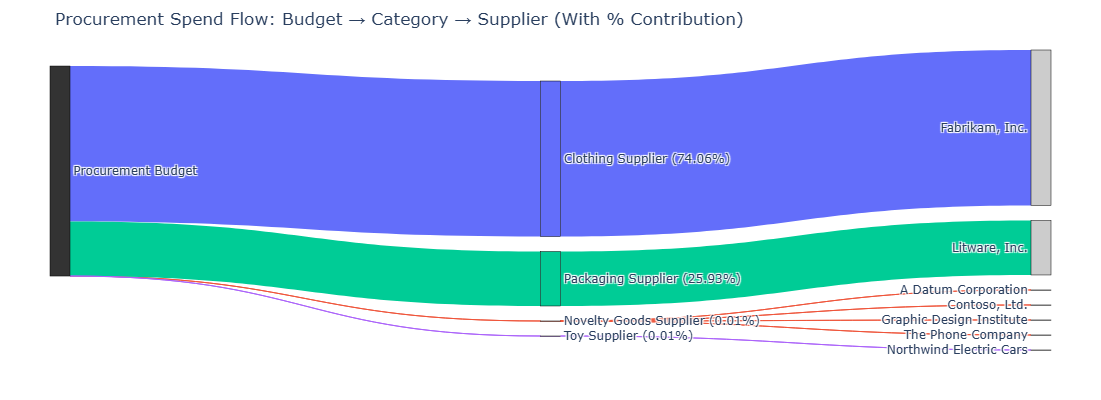

In [36]:
import pandas as pd
import plotly.graph_objects as go
import plotly.colors as colors

# === Prepare Data ===
df = final_df.copy()
df = df.merge(df_dim_supplier[['Supplier', 'Category']], on='Supplier', how='left')

# Group Spend per Category-Supplier
summary = (
    df.groupby(['Category', 'Supplier'])
      .agg({'Total Price': 'sum'})
      .reset_index()
)

# Compute % Contribution per Category
category_totals = summary.groupby('Category')['Total Price'].sum().reset_index()
total_budget = category_totals['Total Price'].sum()
category_totals['Percentage'] = (category_totals['Total Price'] / total_budget * 100).round(2)

# --- Build Node List ---
root_node = ['Procurement Budget']
categories = [f"{row['Category']} ({row['Percentage']}%)" for _, row in category_totals.iterrows()]
suppliers = summary['Supplier'].unique().tolist()

nodes = root_node + categories + suppliers
node_indices = {name: idx for idx, name in enumerate(nodes)}

# Category to original Category mapping
category_label_map = dict(zip(category_totals['Category'], categories))

# --- Color Palette ---
category_colors = colors.qualitative.Plotly[:len(category_totals)]

# --- Build Links ---
# 1. Budget → Category
budget_to_category_links = {
    'source': [node_indices['Procurement Budget']] * len(category_totals),
    'target': [node_indices[category_label_map[cat]] for cat in category_totals['Category']],
    'value': category_totals['Total Price'],
    'color': category_colors,
    'hover': category_totals.apply(lambda row: f"Budget → {row['Category']}<br>${row['Total Price']:,.0f} ({row['Percentage']}%)", axis=1).tolist()
}

# 2. Category → Supplier
category_to_supplier_links = {
    'source': [node_indices[category_label_map[cat]] for cat in summary['Category']],
    'target': [node_indices[sup] for sup in summary['Supplier']],
    'value': summary['Total Price'],
    'color': summary['Category'].map(dict(zip(category_totals['Category'], category_colors))),
    'hover': summary.apply(lambda row: f"{row['Category']} → {row['Supplier']}<br>${row['Total Price']:,.0f}", axis=1).tolist()
}

# Combine Links
source = budget_to_category_links['source'] + category_to_supplier_links['source']
target = budget_to_category_links['target'] + category_to_supplier_links['target']
value = list(budget_to_category_links['value']) + list(category_to_supplier_links['value'])
link_colors = list(budget_to_category_links['color']) + list(category_to_supplier_links['color'])
hover_labels = list(budget_to_category_links['hover']) + list(category_to_supplier_links['hover'])

# === Sankey Diagram ===
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes,
        color= ['#333333'] + category_colors + ['#cccccc']*len(suppliers)  # Budget + Category Colors + Suppliers Gray
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors,
        customdata=hover_labels,
        hovertemplate='%{customdata}<extra></extra>'
    )
)])

fig.update_layout(
    title_text="Procurement Spend Flow: Budget → Category → Supplier (With % Contribution)",
    font_size=12,
    height=400,
    margin=dict(l=50, r=50, t=50, b=50)
)

fig.show()


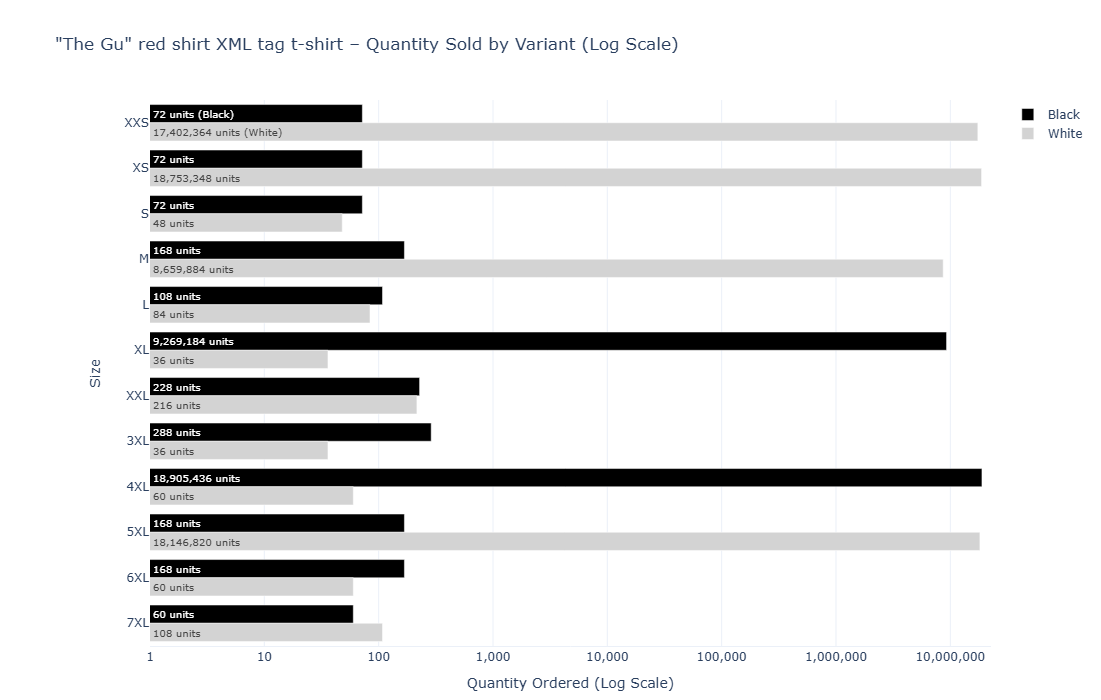

In [59]:
# === Data Preparation ===
pattern = '"The Gu" red shirt XML tag t-shirt'
df_filtered = final_df[final_df['Stock Item'].str.contains(pattern, case=False, na=False)].copy()

df_filtered['Variant'] = df_filtered['Stock Item'].str.replace(
    pattern, '', case=False, regex=False).str.strip()

df_filtered[['Color', 'Size']] = df_filtered['Variant'].str.extract(r'\((.*?)\)\s*(.*)')

summary = df_filtered.groupby(['Color', 'Size']).agg(
    Total_Quantity=('Ordered Quantity', 'sum')
).reset_index()

size_order = ['XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL', 'XXXL', '3XL', '4XL', '5XL', '6XL', '7XL']
summary['Size'] = pd.Categorical(summary['Size'], categories=size_order, ordered=True)

pivot_df = summary.pivot(index='Size', columns='Color', values='Total_Quantity').fillna(1)
pivot_df = pivot_df.sort_index()

# === Build Label Texts ===
# Append (Black) or (White) for the topmost entry only
black_labels = []
white_labels = []

for idx, size in enumerate(pivot_df.index):
    black_qty = int(pivot_df['Black'][size])
    white_qty = int(pivot_df['White'][size])
    
    if idx == 0:
        black_labels.append(f"{black_qty:,} units (Black)")
        white_labels.append(f"{white_qty:,} units (White)")
    else:
        black_labels.append(f"{black_qty:,} units")
        white_labels.append(f"{white_qty:,} units")

# === Build Grouped Bar Chart ===
fig = go.Figure()

# Black Bars
fig.add_trace(go.Bar(
    y=pivot_df.index,
    x=pivot_df['Black'],
    orientation='h',
    name='Black',
    marker_color='black',
    text=black_labels,
    textposition='inside',
    insidetextanchor='start',
    offsetgroup=0
))

# White Bars
fig.add_trace(go.Bar(
    y=pivot_df.index,
    x=pivot_df['White'],
    orientation='h',
    name='White',
    marker_color='lightgray',
    text=white_labels,
    textposition='inside',
    insidetextanchor='start',
    offsetgroup=1
))

# === Layout ===
x_max = pivot_df.values.max() * 1.2  # Padding for visualization

fig.update_layout(
    title='"The Gu" red shirt XML tag t-shirt – Quantity Sold by Variant (Log Scale)',
    xaxis_title='Quantity Ordered (Log Scale)',
    yaxis_title='Size',
    barmode='group',
    template='plotly_white',
    height=700,
    margin=dict(l=150, r=50, t=100, b=50)
)

fig.update_xaxes(
    type='log',
    range=[0, np.log10(x_max)],
    showgrid=True,
    showline=True,
    tickformat=',',
    title='Quantity Ordered (Log Scale)'
)

fig.update_yaxes(autorange='reversed')

fig.show()

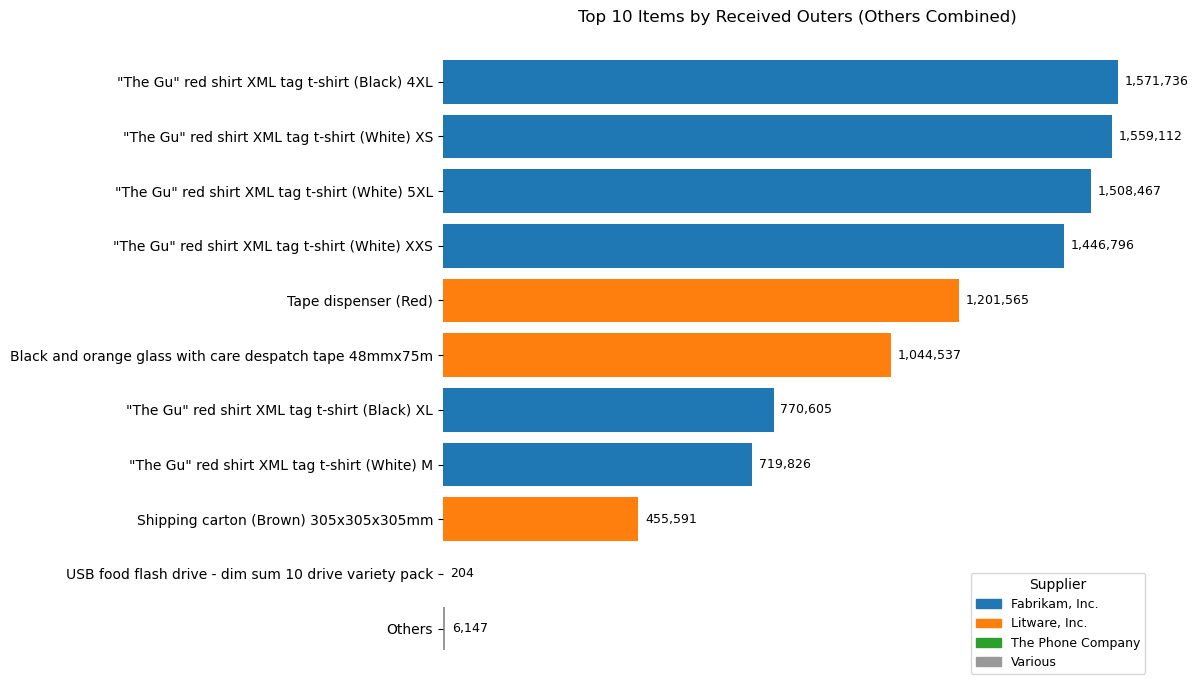

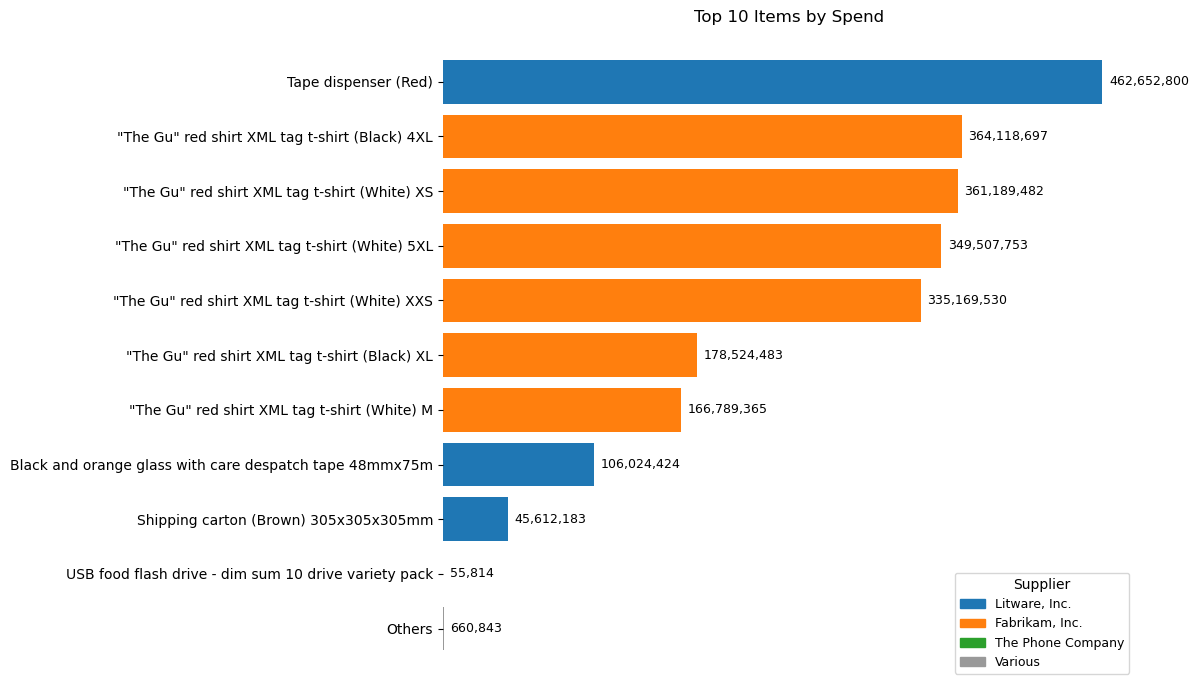

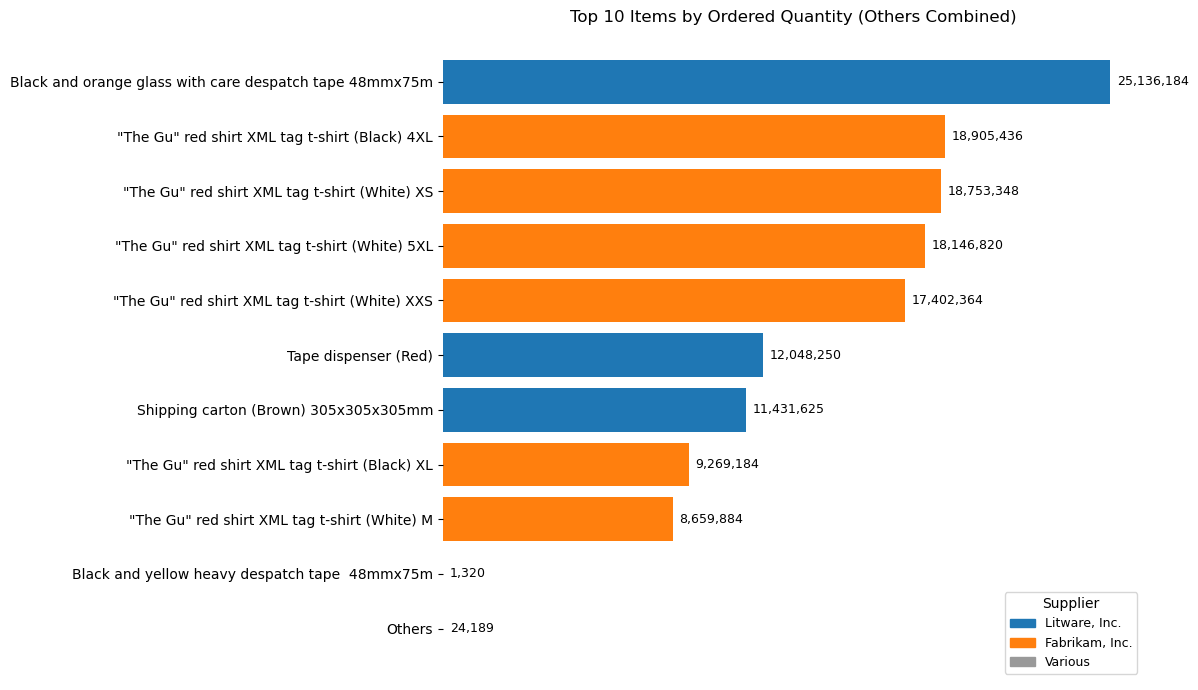

In [38]:
# Top 10 items by received outers
import matplotlib.pyplot as plt
import pandas as pd

def plot_top_items_by_metric(final_df, metric_col, top_n=10, title=None):
    # Step 1: Aggregate total metric per Stock Item + Supplier
    item_metric = (
        final_df.groupby(['Stock Item', 'Supplier'])[metric_col]
        .sum()
        .reset_index()
    )

    # Step 2: Get top N Stock Items by total metric
    top_items = (
        item_metric.groupby('Stock Item')[metric_col]
        .sum()
        .nlargest(top_n)
        .index
    )

    # Step 3: Filter top and others
    top_df = item_metric[item_metric['Stock Item'].isin(top_items)]

    # Pick the supplier with highest contribution for each item
    top_main = (
        top_df.sort_values(['Stock Item', metric_col], ascending=[True, False])
        .drop_duplicates('Stock Item')
    )

    # Step 4: Create "Others" row
    others_total = item_metric[~item_metric['Stock Item'].isin(top_items)][metric_col].sum()
    others_row = pd.DataFrame({
        'Stock Item': ['Others'],
        'Supplier': ['Various'],
        metric_col: [others_total]
    })

    # Step 5: Combine
    plot_data = pd.concat([top_main, others_row], ignore_index=True)

    # Step 6: Sort (Others last)
    plot_data = plot_data.sort_values(by=metric_col, ascending=False)
    plot_data = pd.concat([
        plot_data[plot_data['Stock Item'] != 'Others'],
        plot_data[plot_data['Stock Item'] == 'Others']
    ])

    # Step 7: Color mapping
    unique_suppliers = plot_data['Supplier'].unique().tolist()
    color_map = {supplier: plt.cm.tab10(i % 10) for i, supplier in enumerate(unique_suppliers)}
    color_map['Various'] = '#999999'

    # Step 8: Plot
    fig, ax = plt.subplots(figsize=(12, 7))

    bars = ax.barh(
        plot_data['Stock Item'],
        plot_data[metric_col],
        color=[color_map[supplier] for supplier in plot_data['Supplier']]
    )

    # Add labels
    for bar in bars:
        width = int(bar.get_width())
        ax.text(
            width + plot_data[metric_col].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,}",
            va='center',
            fontsize=9
        )

    # Aesthetics
    ax.set_title(
        title or f"Top {top_n} Items by {metric_col.replace('_', ' ').title()} (Others Combined)",
        fontsize=12
    )
    ax.invert_yaxis()
    ax.xaxis.set_ticks([])
    ax.ticklabel_format(style='plain', axis='x')

    # Remove plot borders
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Legend
    handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[s]) for s in unique_suppliers]
    ax.legend(handles, unique_suppliers, title='Supplier', loc='lower right', fontsize=9, title_fontsize=10)

    plt.tight_layout()
    plt.show()

# For Received Outers
plot_top_items_by_metric(final_df, 'Received Outers')

# For Total Price
plot_top_items_by_metric(final_df, 'Total Price', title='Top 10 Items by Spend')

# For Ordered Quantity
plot_top_items_by_metric(final_df, 'Ordered Quantity')

In [107]:
import pandas as pd
import dash
from dash import dcc, html, Input, Output
import plotly.graph_objects as go

# ==== Prepare Data ====
df = final_df.copy()
df['Year'] = pd.to_datetime(df['Date Key']).dt.year

summary = (
    df.groupby('Year').agg({
        'Total Price': 'sum',
        'Received Outers': 'sum'
    }).reset_index()
)

# ==== Dash App ====
app = dash.Dash(__name__)
app.title = "Purchases and Outers by Year"

app.layout = html.Div([
    html.H2("Total Purchases and Outers by Year"),

    dcc.Graph(id='purchase-chart'),

    html.Div([
        html.Label("📊 Bar : Line Height Ratio"),
        dcc.Slider(
            id='bar-line-ratio',
            min=0.2, max=3.0, step=0.1, value=1.0,
            marks={0.5: "0.5x", 1: "1x", 2: "2x", 3: "3x"}
        )
    ], style={'margin': '20px 0'}),

    html.Div([
        html.Label("📏 Total Figure Height"),
        dcc.Slider(
            id='fig-height',
            min=300, max=900, step=50, value=500,
            marks={300: '300px', 500: '500px', 700: '700px', 900: '900px'}
        )
    ], style={'margin': '20px 0'})
])


# ==== Callback ====
@app.callback(
    Output('purchase-chart', 'figure'),
    Input('bar-line-ratio', 'value'),
    Input('fig-height', 'value')
)
def update_chart(ratio, fig_height):
    df_plot = summary.copy()

    # Reference max values
    max_bar = df_plot['Received Outers'].max()
    max_line = df_plot['Total Price'].max()

    # Adjust bar scale relative to line chart using ratio
    bar_scale = (max_line / max_bar) * (ratio / (1 + ratio))
    line_scale = (max_line / max_line) * (1 / (1 + ratio))

    # Apply scale
    df_plot['Scaled Outers'] = df_plot['Received Outers'] * bar_scale
    df_plot['Total Price Raised'] = df_plot['Total Price'] * line_scale
    df_plot['Total Price Label'] = df_plot['Total Price Raised'] * 1.05

    fig = go.Figure()

    # Bar
    fig.add_trace(go.Bar(
        x=df_plot['Year'].astype(str),
        y=df_plot['Scaled Outers'],
        name='Total Outers',
        marker_color='rgba(10, 30, 40, 0.95)',
        text=[f"{int(v):,}" for v in df_plot['Received Outers']],
        textposition='outside',
        textfont=dict(size=14),
        hovertemplate='Outers: %{text}<extra></extra>'
    ))

    # Line
    fig.add_trace(go.Scatter(
        x=df_plot['Year'].astype(str),
        y=df_plot['Total Price Raised'],
        name='Total Purchases',
        mode='lines+markers',
        line=dict(color='firebrick', width=2),
        marker=dict(size=8),
        yaxis='y2',
        hovertemplate='Purchases: $%{y:,.0f}<extra></extra>'
    ))

    # Shadow text
    fig.add_trace(go.Scatter(
        x=df_plot['Year'].astype(str),
        y=df_plot['Total Price Label'],
        mode='text',
        text=[f"${int(v):,}" for v in df_plot['Total Price']],
        textposition='top center',
        textfont=dict(size=18, color='rgba(255,255,255,0.4)'),
        showlegend=False,
        hoverinfo='skip'
    ))

    # Foreground text
    fig.add_trace(go.Scatter(
        x=df_plot['Year'].astype(str),
        y=df_plot['Total Price Label'],
        mode='text',
        text=[f"${int(v):,}" for v in df_plot['Total Price']],
        textposition='top center',
        textfont=dict(size=14, color='firebrick'),
        showlegend=False,
        hoverinfo='skip'
    ))

    # Layout
    fig.update_layout(
        title='Total Purchases and Outers by Year',
        template='plotly_white',
        height=fig_height,
        title_x=0.5,
        barmode='group',
        xaxis=dict(title=''),
        yaxis=dict(
            title='',
            showticklabels=False,
            showline=False,
            showgrid=False
        ),
        yaxis2=dict(
            overlaying='y',
            side='right',
            showticklabels=False,
            showline=False,
            showgrid=False
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='left',
            x=0.01,
            font=dict(size=12)
        )
    )

    return fig


# ==== Run ====
if __name__ == '__main__':
    app.run(port=8073, debug=False)


C:\Users\farrel.mahardika\AppData\Local\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



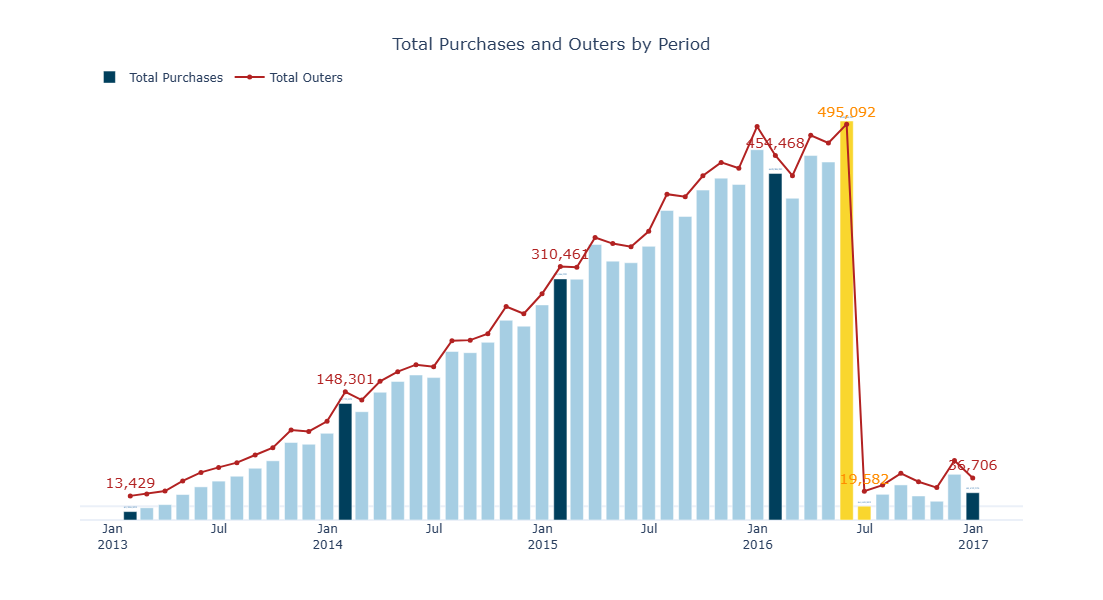

In [115]:
# ==== Data Preparation ====
df = final_df.copy()
df['Date'] = pd.to_datetime(df['Date Key'])

# Group by start of month (aligning bar correctly to the calendar month)
df['MonthStart'] = df['Date'].dt.to_period('M').dt.to_timestamp('M')  # Month start

monthly_summary = (
    df.groupby('MonthStart')
      .agg({
          'Total Price': 'sum',
          'Received Outers': 'sum'
      })
      .reset_index()
      .rename(columns={'MonthStart': 'Date'})
)

monthly_summary['Month'] = monthly_summary['Date'].dt.month
monthly_summary['Year'] = monthly_summary['Date'].dt.year
final_month = monthly_summary['Date'].max()

# ==== Color Mapping ====
def get_bar_color(row):
    if row['Date'] == final_month or row['Month'] == 1:
        return '#003f5c'  # Dark blue
    elif row['Year'] == 2016 and row['Month'] in [5, 6]:
        return '#f9d62e'  # Yellow
    else:
        return '#a6cee3'  # Light blue

monthly_summary['bar_color'] = monthly_summary.apply(get_bar_color, axis=1)
monthly_summary['show_bar_label'] = (
    (monthly_summary['Month'] == 1) |
    ((monthly_summary['Year'] == 2016) & (monthly_summary['Month'].isin([5, 6]))) |
    (monthly_summary['Date'] == final_month)
)
monthly_summary['show_line_label'] = monthly_summary['show_bar_label']

# ==== Plotly Chart ====
fig = go.Figure()

# === Bar Chart: Total Purchases ===
fig.add_trace(go.Bar(
    x=monthly_summary['Date'],
    y=monthly_summary['Total Price'],
    name='Total Purchases',
    marker_color=monthly_summary['bar_color'],
    text=[f"${v:,.0f}" if flag else '' for v, flag in zip(monthly_summary['Total Price'], monthly_summary['show_bar_label'])],
    textposition='outside',
    textfont=dict(color='steelblue', size=28),
    yaxis='y1'
))

# === Line Chart: Total Outers ===
fig.add_trace(go.Scatter(
    x=monthly_summary['Date'],
    y=monthly_summary['Received Outers'],
    name='Total Outers',
    mode='lines+markers+text',
    line=dict(color='firebrick', width=2),
    marker=dict(size=5),
    text=[f"{int(v):,}" if flag else '' for v, flag in zip(monthly_summary['Received Outers'], monthly_summary['show_line_label'])],
    textposition='top center',
    textfont=dict(
        size=14,
        color=[
            'darkorange' if (y == 2016 and m in [5, 6])
            else 'firebrick'
            for y, m in zip(monthly_summary['Year'], monthly_summary['Month'])
        ]
    ),
    yaxis='y2'
))

# === Layout ===
fig.update_layout(
    title='Total Purchases and Outers by Period',
    xaxis=dict(title='', tickformat='%b\n%Y'),

    # === Graph Size (adjust these) ===
    height=600,
    width=1200,

    template='plotly_white',
    title_x=0.5,
    barmode='group',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='left',
        x=0.01,
        font=dict(size=12)
    ),
    yaxis=dict(
        title='',
        showticklabels=False,
        showgrid=False,
        showline=False
    ),
    yaxis2=dict(
        overlaying='y',
        side='right',
        showticklabels=False,
        showgrid=False,
        showline=False
    )
)

fig.show()


In [1]:
import pandas as pd
import plotly.graph_objects as go

# === Data Preparation ===
df = final_df.copy()
df['Date'] = pd.to_datetime(df['Date Key'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Monthly aggregation
monthly_summary = (
    df.groupby(pd.Grouper(key='Date', freq='M'))
      .agg({
          'Total Price': 'sum',
          'Received Outers': 'sum'
      })
      .reset_index()
)

# Identify key months for annotations
final_month = monthly_summary['Date'].max()
max_outers_month = monthly_summary.loc[monthly_summary['Received Outers'].idxmax(), 'Date']
after_max_outers_month = max_outers_month + pd.DateOffset(months=1)

# Generate label flags for specific months
monthly_summary['Show_Label'] = monthly_summary['Date'].apply(
    lambda d: d.month == 1 or d == final_month or d == max_outers_month or d == after_max_outers_month
)

# X-axis labels: Only for Januarys
x_labels = monthly_summary['Date'].dt.strftime('%b\n%Y').where(monthly_summary['Date'].dt.month == 1)

# === Plotly Chart ===
fig = go.Figure()

# === Bar Chart: Total Purchases ===
fig.add_trace(go.Bar(
    x=monthly_summary['Date'],
    y=monthly_summary['Total Price'],
    name='Total Purchases',
    marker_color='rgba(10, 30, 60, 0.4)',  # Dark blue with 40% opacity
    yaxis='y1',
    hovertemplate='$%{y:,.0f}<extra></extra>'
))

# === Line Chart: Number of Outers ===
fig.add_trace(go.Scatter(
    x=monthly_summary['Date'],
    y=monthly_summary['Received Outers'],
    mode='lines+markers+text',
    name='Number of Outers',
    line=dict(color='firebrick', width=2),
    marker=dict(size=7, color='firebrick'),
    text=[f"{int(v):,}" if flag else '' for v, flag in zip(monthly_summary['Received Outers'], monthly_summary['Show_Label'])],
    textposition='top center',
    textfont=dict(size=12, color='firebrick'),
    yaxis='y2',
    hovertemplate='Outers: %{y:,}<extra></extra>'
))

# === Layout ===
fig.update_layout(
    title='Monthly Total Purchases and Number of Outers',
    template='plotly_white',
    height=500,
    xaxis=dict(
        title='',
        tickmode='array',
        tickvals=monthly_summary['Date'],
        ticktext=x_labels,
        tickangle=0
    ),
    yaxis=dict(
        title='Total Purchases',
        showline=False,
        showgrid=False,
        tickformat=',',  # Thousands separator
        rangemode='tozero'  # Force Y-axis to start at 0
    ),
    yaxis2=dict(
        overlaying='y',
        side='right',
        showticklabels=False,
        showline=False,
        showgrid=False,
        rangemode='tozero'  # Line Y-axis starts at 0
    ),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0.01)
)

fig.show()


NameError: name 'final_df' is not defined

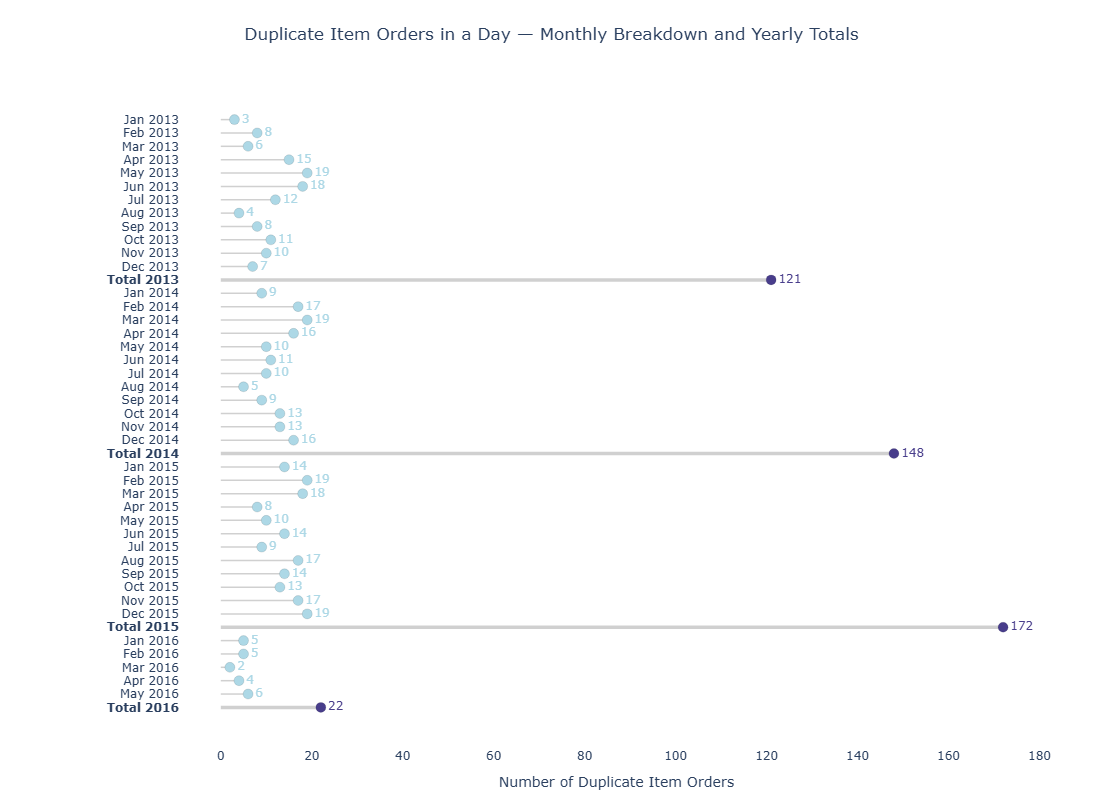

In [117]:
import pandas as pd
import plotly.graph_objects as go

# === Step 1: Prepare Data ===
df = final_df.copy()
df['Date'] = pd.to_datetime(df['Date Key'])
df['Date_only'] = df['Date'].dt.date

# Identify same item ordered more than once in a day
duplicates = (
    df.groupby(['Supplier', 'Date_only', 'Stock Item'])
    .size()
    .reset_index(name='Order Count')
)
duplicates = duplicates[duplicates['Order Count'] > 1]

# Convert to month
duplicates['Month'] = pd.to_datetime(duplicates['Date_only']).dt.to_period('M').dt.to_timestamp()
monthly_count = (
    duplicates.groupby('Month')
    .size()
    .reset_index(name='Monthly Duplicates')
)
monthly_count['Year'] = monthly_count['Month'].dt.year

# === Step 2: Build Lollipop Data ===
points = []
lines = []
texts = []
colors = []
line_widths = []
ticktext = []

monthly_color = 'lightblue'
yearly_color = 'darkslateblue'

cumulative = 0
for i, row in monthly_count.iterrows():
    month_str = row['Month'].strftime('%b %Y')
    year = row['Year']
    val = row['Monthly Duplicates']

    # Month point
    points.append(month_str)
    lines.append(val)
    texts.append(str(val))
    colors.append(monthly_color)
    line_widths.append(1.5)
    ticktext.append(month_str)

    cumulative += val

    # Add yearly total
    is_last_month = (i + 1 == len(monthly_count)) or (monthly_count.loc[i + 1, 'Year'] != year)
    if is_last_month:
        total_label = f"Total {year}"
        points.append(total_label)
        lines.append(cumulative)
        texts.append(str(cumulative))
        colors.append(yearly_color)
        line_widths.append(3.5)
        ticktext.append(f"<b>{total_label}</b>")
        cumulative = 0

# === Step 3: Build Figure ===
fig = go.Figure()

# Add sticks
for i, val in enumerate(lines):
    fig.add_shape(
        type='line',
        x0=0,
        x1=val,
        y0=i,
        y1=i,
        line=dict(color='rgba(100,100,100,0.3)', width=line_widths[i]),
        layer='below'
    )

# Add lollipop dots and labels
fig.add_trace(go.Scatter(
    x=lines,
    y=list(range(len(points))),
    mode='markers+text',
    marker=dict(
        size=10,
        color=colors,
        line=dict(width=1, color='rgba(0,0,0,0.1)')
    ),
    text=texts,
    textposition='middle right',
    textfont=dict(size=12, color=colors),
    hoverinfo='x+y',
    showlegend=False
))

# === Step 4: Custom Axis & Layout ===

# Alternating Y label padding
tickvals = list(range(len(points)))
ticktext_alternating = []
for i, txt in enumerate(ticktext):
    space = '\u2003' * (3 if i % 2 == 0 else 0)  # 3 em-spaces every other label
    ticktext_alternating.append(f"{space}{txt}")



fig.update_yaxes(
    tickvals=tickvals,
    ticktext=ticktext_alternating,
    autorange='reversed',
    showgrid=False,     # remove horizontal gridlines
    zeroline=False      # remove axis line at x=0
)

fig.update_xaxes(
    title='Number of Duplicate Item Orders',
    showgrid=False,     # remove vertical gridlines
    zeroline=False
)

fig.update_layout(
    title='Duplicate Item Orders in a Day — Monthly Breakdown and Yearly Totals',
    height=800,   # Adjust height here
    width=800,   # Adjust width here
    margin=dict(l=180, r=50, t=80, b=50),
    template='plotly_white',
    title_x=0.5
)

fig.show()


🔍 Total spent on Tape Dispenser (Red): $462,652,800.00
📊 Percentage of total spending: 19.52%


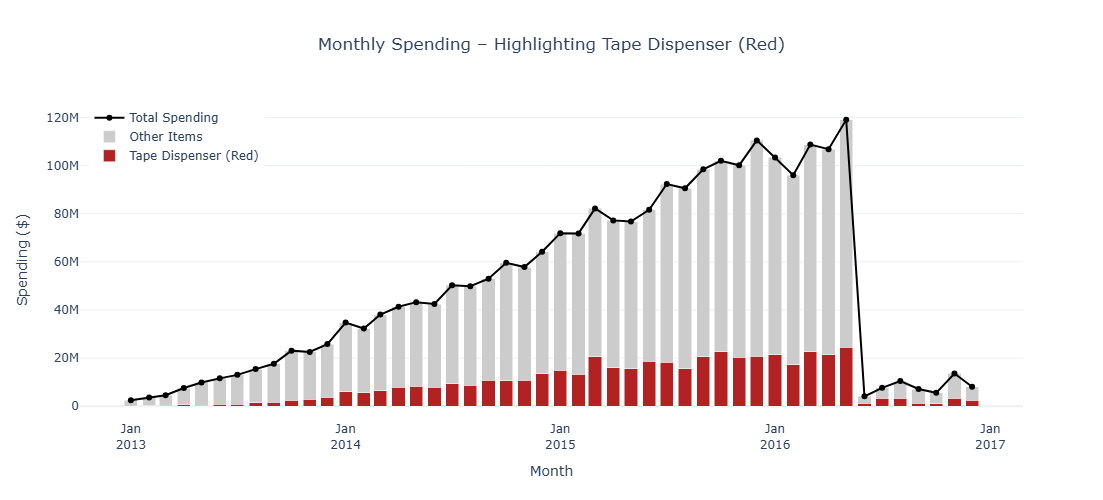

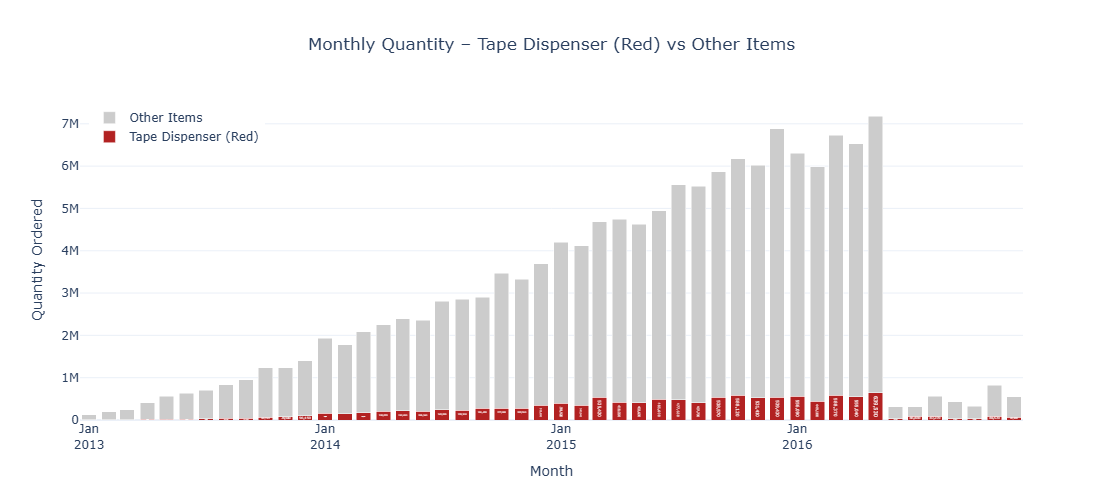

In [34]:
#===HIGHLIGHT TAPE DISPENSER===#
import pandas as pd
import plotly.graph_objects as go

# === STEP 1: Prepare ===
df = final_df.copy()
df['Date'] = pd.to_datetime(df['Date Key'])
df['YearMonth'] = df['Date'].dt.to_period('M').dt.to_timestamp()

# Identify red tape dispenser
df['Is_Tape_Red'] = df['Stock Item'].str.lower().str.contains('tape dispenser') & df['Stock Item'].str.lower().str.contains('red')

# === STEP 2: Monthly spending and quantity ===
monthly_group = df.groupby(['YearMonth', 'Is_Tape_Red']).agg(
    Total_Spending=('Total Price', 'sum'),
    Total_Quantity=('Ordered Quantity', 'sum')
).unstack(fill_value=0)

# Rename columns
monthly = monthly_group.copy()
monthly.columns = ['Other_Spending', 'Red_Spending', 'Other_Quantity', 'Red_Quantity'] \
    if True in df['Is_Tape_Red'].unique() else ['Other_Spending', 'Other_Quantity']
monthly = monthly.reset_index()

# Fill in zeros if Tape Red never appears
if 'Red_Spending' not in monthly.columns:
    monthly['Red_Spending'] = 0
if 'Red_Quantity' not in monthly.columns:
    monthly['Red_Quantity'] = 0

# Total columns
monthly['Total_Spending'] = monthly['Other_Spending'] + monthly['Red_Spending']
monthly['Total_Quantity'] = monthly['Other_Quantity'] + monthly['Red_Quantity']

# === STEP 3: Spending Chart ===
fig1 = go.Figure()

# Red Tape Spending
fig1.add_trace(go.Bar(
    x=monthly['YearMonth'],
    y=monthly['Red_Spending'],
    name='Tape Dispenser (Red)',
    marker_color='firebrick'
))

# Other Spending
fig1.add_trace(go.Bar(
    x=monthly['YearMonth'],
    y=monthly['Other_Spending'],
    name='Other Items',
    marker_color='#CCCCCC'
))

# Total Spending Line
fig1.add_trace(go.Scatter(
    x=monthly['YearMonth'],
    y=monthly['Total_Spending'],
    mode='lines+markers',
    name='Total Spending',
    line=dict(color='black', width=2)
))

# Layout for spending chart
fig1.update_layout(
    barmode='stack',
    title='Monthly Spending – Highlighting Tape Dispenser (Red)',
    xaxis_title='Month',
    yaxis_title='Spending ($)',
    template='plotly_white',
    height=500,
    width=700,
    legend=dict(x=0.01, y=0.99),
    title_x=0.5,
    xaxis=dict(
        tickformat='%b\n%Y',
        dtick='M12',  # show label every 12 months
        tickangle=0
    )
)

# === STEP 4: Quantity Chart ===
fig2 = go.Figure()

# Red Tape Quantity with label
fig2.add_trace(go.Bar(
    x=monthly['YearMonth'],
    y=monthly['Red_Quantity'],
    name='Tape Dispenser (Red)',
    marker_color='firebrick',
    text=[f"{int(q):,}" if q > 0 else "" for q in monthly['Red_Quantity']],
    textposition='outside'
))

# Other Quantity
fig2.add_trace(go.Bar(
    x=monthly['YearMonth'],
    y=monthly['Other_Quantity'],
    name='Other Items',
    marker_color='#CCCCCC'
))

# Layout for quantity chart
fig2.update_layout(
    barmode='stack',
    title='Monthly Quantity – Tape Dispenser (Red) vs Other Items',
    xaxis_title='Month',
    yaxis_title='Quantity Ordered',
    template='plotly_white',
    height=500,
    width=600,
    legend=dict(x=0.01, y=0.99),
    title_x=0.5,
    xaxis=dict(
        tickformat='%b\n%Y',
        dtick='M12',  # show yearly interval
        tickangle=0
    )
)

# === STEP 5: Percent Summary ===
total_spent = df['Total Price'].sum()
red_spent = df[df['Is_Tape_Red']]['Total Price'].sum()
percent = (red_spent / total_spent) * 100 if total_spent > 0 else 0

print(f"🔍 Total spent on Tape Dispenser (Red): ${red_spent:,.2f}")
print(f"📊 Percentage of total spending: {percent:.2f}%")

# === STEP 6: Show Charts ===
fig1.show()
fig2.show()


C:\Users\farrel.mahardika\AppData\Local\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



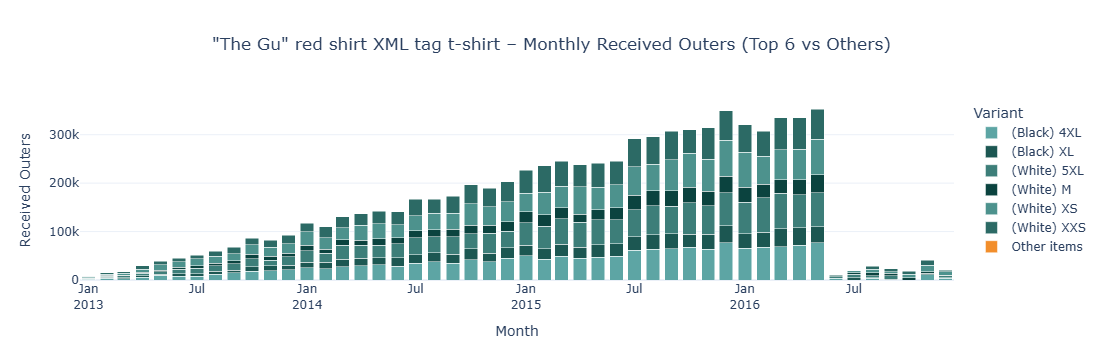

In [132]:
#===THE GU T-SHIRT PURCHASES===#
import pandas as pd
import plotly.express as px

# === STEP 1: Filter relevant items ===
pattern = '"The Gu" red shirt XML tag t-shirt'
df_filtered = final_df[final_df['Stock Item'].str.contains(pattern, case=False, na=False)].copy()

# Extract variant
df_filtered['Variant'] = df_filtered['Stock Item'].str.replace(
    pattern, '', case=False, regex=False).str.strip()

# Add Year-Month
df_filtered['Month'] = pd.to_datetime(df_filtered['Date Key']).dt.to_period('M').dt.to_timestamp()

# === STEP 2: Determine top 6 by total Received Outers ===
top_variants = (
    df_filtered.groupby('Variant')['Received Outers']
    .sum()
    .nlargest(6)
    .index
)

# Label variants (top 6 stay, others become "Other items")
df_filtered['Variant Group'] = df_filtered['Variant'].apply(
    lambda x: x if x in top_variants else 'Other items'
)

# === STEP 3: Aggregate monthly received outers ===
monthly_data = (
    df_filtered.groupby(['Month', 'Variant Group'])['Received Outers']
    .sum()
    .reset_index()
)

# === STEP 4: Color mapping ===
top_colors = [
    '#5DA5A4', '#4D928D', '#3D7E79',
    '#2C6A65', '#1C5752', '#0B433F'  # Muted blue-green shades
]
color_map = {variant: top_colors[i] for i, variant in enumerate(top_variants)}
color_map['Other items'] = '#F28E2B'  # Bright orange for "others"

# === STEP 5: Plotly Stacked Bar Chart ===
fig = px.bar(
    monthly_data,
    x='Month',
    y='Received Outers',
    color='Variant Group',
    title='"The Gu" red shirt XML tag t-shirt – Monthly Received Outers (Top 6 vs Others)',
    labels={'Received Outers': 'Received Outers', 'Month': 'Month'},
    color_discrete_map=color_map,
    template='plotly_white'
)

fig.update_layout(
    barmode='stack',
    height=550,
    title_x=0.5,
    xaxis=dict(tickformat='%b\n%Y'),
    legend_title='Variant'
)

fig.show()


In [ ]:
import pandas as pd

# Step 1: Set item name and date
item_name = '"The Gu" Red Shirt XML tag t-shirt (White) 5XL'
target_date = pd.to_datetime('2015-08-01').date()

# Step 2: Filter matching orders
filtered_df = final_df[
    (final_df['Stock Item'] == item_name) &
    (final_df['Date Key'].dt.date == target_date)
]

# Step 3: Check if all quantities are the same
unique_quantities = filtered_df['Ordered Quantity'].unique()

# Step 4: Print summary
print("=== Order Summary on 2015-08-01 ===")
print(filtered_df[['Purchase Key', 'Ordered Quantity']])

if len(unique_quantities) == 1:
    print("\n✅ All orders have the same quantity:", unique_quantities[0])
else:
    print("\n❌ Orders have different quantities:", unique_quantities)


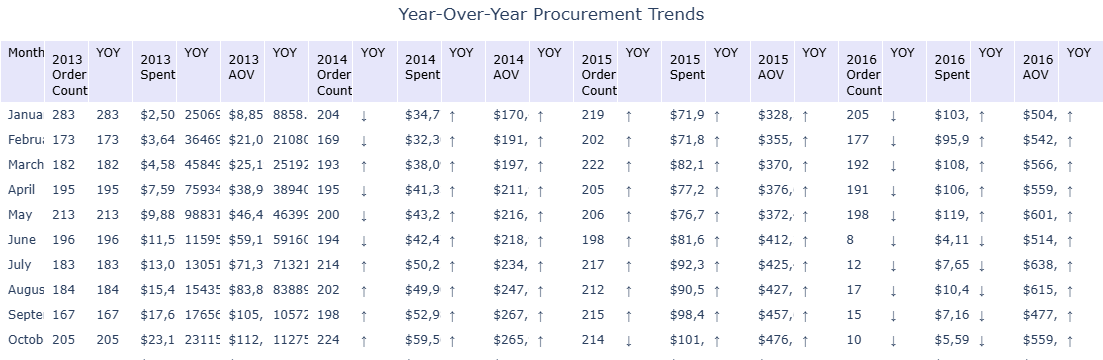

In [136]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

df = final_df.copy()
df['Year'] = pd.to_datetime(df['Date Key']).dt.year
df['MonthNum'] = pd.to_datetime(df['Date Key']).dt.month
df['MonthName'] = pd.to_datetime(df['Date Key']).dt.strftime('%B')

# Aggregate Monthly Procurement Metrics
monthly_summary = (
    df.groupby(['Year', 'MonthNum', 'MonthName'])
      .agg({
          'Purchase Key': 'nunique',       # Order Count
          'Total Price': 'sum'
      })
      .rename(columns={'Purchase Key': 'Order Count', 'Total Price': 'Total Spent'})
      .reset_index()
)

# Calculate AOV
monthly_summary['AOV'] = monthly_summary['Total Spent'] / monthly_summary['Order Count']

# Ensure consistent month order
monthly_summary['MonthName'] = pd.Categorical(
    monthly_summary['MonthName'],
    categories=[
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ],
    ordered=True
)

# Sort
monthly_summary.sort_values(by=['MonthNum', 'Year'], inplace=True)

# Pivot for each metric to create table view
pivot_tables = {}
metrics = ['Order Count', 'Total Spent', 'AOV']
for metric in metrics:
    pivot = monthly_summary.pivot(index='MonthName', columns='Year', values=metric)
    pivot_tables[metric] = pivot

# Compute YOY Arrows
def compute_yoy_arrow(df):
    arrow_df = df.copy()
    for col in df.columns[1:]:
        prev_col = df.columns[df.columns.get_loc(col)-1]
        arrow_df[col] = np.where(df[col] > df[prev_col], '↑', '↓')
    return arrow_df

pivot_yoy = {metric: compute_yoy_arrow(pivot_tables[metric]) for metric in metrics}

# Build Plotly Table Rows
months = pivot_tables['Order Count'].index.tolist()
years = pivot_tables['Order Count'].columns.tolist()

header = ["Month"]
for y in years:
    header.extend([
        f"{y} Order Count", "YOY",
        f"{y} Spent", "YOY",
        f"{y} AOV", "YOY"
    ])

# Construct table rows
rows = []
for month in months:
    row = [month]
    for y in years:
        oc = pivot_tables['Order Count'].loc[month, y] if y in pivot_tables['Order Count'].columns else ''
        oc_yoy = pivot_yoy['Order Count'].loc[month, y] if y in pivot_yoy['Order Count'].columns else ''
        ts = pivot_tables['Total Spent'].loc[month, y] if y in pivot_tables['Total Spent'].columns else ''
        ts_yoy = pivot_yoy['Total Spent'].loc[month, y] if y in pivot_yoy['Total Spent'].columns else ''
        aov = pivot_tables['AOV'].loc[month, y] if y in pivot_tables['AOV'].columns else ''
        aov_yoy = pivot_yoy['AOV'].loc[month, y] if y in pivot_yoy['AOV'].columns else ''
        
        row.extend([
            f"{int(oc):,}" if oc != '' else '',
            oc_yoy,
            f"${ts:,.0f}" if ts != '' else '',
            ts_yoy,
            f"${aov:,.0f}" if aov != '' else '',
            aov_yoy
        ])
    rows.append(row)

# === Plotly Table ===
fig = go.Figure(data=[go.Table(
    header=dict(
        values=header,
        fill_color='lavender',
        align='left',
        font=dict(size=12, color='black'),
        height=30
    ),
    cells=dict(
        values=list(map(list, zip(*rows))),
        fill_color='white',
        align='left',
        font=dict(size=12),
        height=25
    )
)])

fig.update_layout(
    title='Year-Over-Year Procurement Trends',
    title_x=0.5,
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()


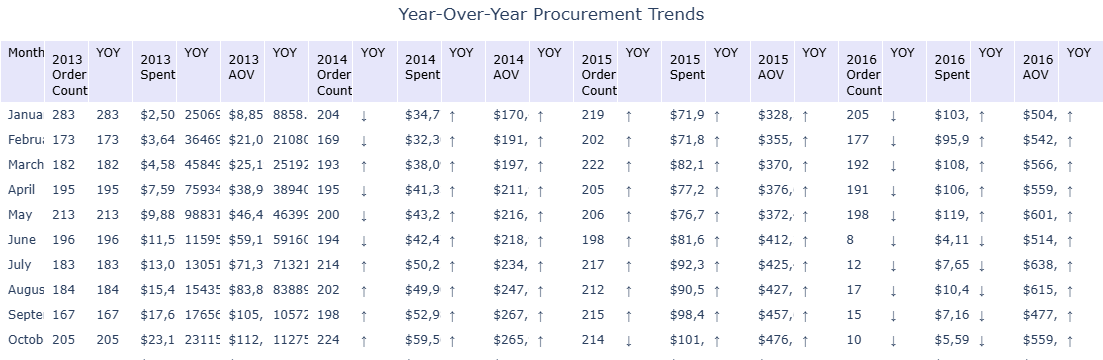

In [145]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

df = final_df.copy()
df['Year'] = pd.to_datetime(df['Date Key']).dt.year
df['MonthNum'] = pd.to_datetime(df['Date Key']).dt.month
df['MonthName'] = pd.to_datetime(df['Date Key']).dt.strftime('%B')

# Aggregate Monthly Procurement Metrics
monthly_summary = (
    df.groupby(['Year', 'MonthNum', 'MonthName'])
      .agg({
          'Purchase Key': 'nunique',       # Order Count
          'Total Price': 'sum'
      })
      .rename(columns={'Purchase Key': 'Order Count', 'Total Price': 'Total Spent'})
      .reset_index()
)

# Calculate AOV
monthly_summary['AOV'] = monthly_summary['Total Spent'] / monthly_summary['Order Count']

# Ensure consistent month order
monthly_summary['MonthName'] = pd.Categorical(
    monthly_summary['MonthName'],
    categories=[
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ],
    ordered=True
)

# Sort
monthly_summary.sort_values(by=['MonthNum', 'Year'], inplace=True)

# Pivot for each metric to create table view
pivot_tables = {}
metrics = ['Order Count', 'Total Spent', 'AOV']
for metric in metrics:
    pivot = monthly_summary.pivot(index='MonthName', columns='Year', values=metric)
    pivot_tables[metric] = pivot

# Compute YOY Arrows
def compute_yoy_arrow(df):
    arrow_df = df.copy()
    for col in df.columns[1:]:
        prev_col = df.columns[df.columns.get_loc(col)-1]
        arrow_df[col] = np.where(df[col] > df[prev_col], '↑', '↓')
    return arrow_df

pivot_yoy = {metric: compute_yoy_arrow(pivot_tables[metric]) for metric in metrics}

# Build Plotly Table Rows
months = pivot_tables['Order Count'].index.tolist()
years = pivot_tables['Order Count'].columns.tolist()

header = ["Month"]
for y in years:
    header.extend([
        f"{y} Order Count", "YOY",
        f"{y} Spent", "YOY",
        f"{y} AOV", "YOY"
    ])

# Construct table rows
rows = []
for month in months:
    row = [month]
    for y in years:
        oc = pivot_tables['Order Count'].loc[month, y] if y in pivot_tables['Order Count'].columns else ''
        oc_yoy = pivot_yoy['Order Count'].loc[month, y] if y in pivot_yoy['Order Count'].columns else ''
        ts = pivot_tables['Total Spent'].loc[month, y] if y in pivot_tables['Total Spent'].columns else ''
        ts_yoy = pivot_yoy['Total Spent'].loc[month, y] if y in pivot_yoy['Total Spent'].columns else ''
        aov = pivot_tables['AOV'].loc[month, y] if y in pivot_tables['AOV'].columns else ''
        aov_yoy = pivot_yoy['AOV'].loc[month, y] if y in pivot_yoy['AOV'].columns else ''
        
        row.extend([
            f"{int(oc):,}" if oc != '' else '',
            oc_yoy,
            f"${ts:,.0f}" if ts != '' else '',
            ts_yoy,
            f"${aov:,.0f}" if aov != '' else '',
            aov_yoy
        ])
    rows.append(row)

# === Plotly Table ===
fig = go.Figure(data=[go.Table(
    header=dict(
        values=header,
        fill_color='lavender',
        align='left',
        font=dict(size=12, color='black'),
        height=30
    ),
    cells=dict(
        values=list(map(list, zip(*rows))),
        fill_color='white',
        align='left',
        font=dict(size=12),
        height=25
    )
)])

fig.update_layout(
    title='Year-Over-Year Procurement Trends',
    title_x=0.5,
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()


In [148]:
import pandas as pd
from graphviz import Digraph
from IPython.display import display

# === STEP 1: List of your dataframes ===
dfs = {
    "final_df": final_df,
    "df_dim_supplier": df_dim_supplier,
    "df_dim_stock_item": df_dim_stock_item
}

# === STEP 2: Create table of column names and dtypes ===
metadata = []
for name, df in dfs.items():
    for col in df.columns:
        dtype = df[col].dtype
        metadata.append([name, col, str(dtype)])

df_schema = pd.DataFrame(metadata, columns=["DataFrame", "Column", "DType"])

# Display schema in notebook
display(df_schema)

# Optional: Save schema as CSV
df_schema.to_csv("dataframe_schema.csv", index=False)

# === STEP 3: Draw database relationship diagram ===
# Customize your relationships
relationships = [
    ("df_dim_supplier", "Supplier", "final_df", "Supplier"),
    ("df_dim_stock_item", "Stock Item", "final_df", "Stock Item")
]

# Create Graphviz Digraph
dot = Digraph(comment="Data Model Diagram")
dot.attr(rankdir="LR", bgcolor="white", fontname="Arial")

# Add nodes (one per table)
for df_name in dfs:
    columns = dfs[df_name].columns
    label = f"<<TABLE BORDER='1' CELLBORDER='0' CELLSPACING='0'>"
    label += f"<TR><TD BGCOLOR='lightblue'><B>{df_name}</B></TD></TR>"
    for col in columns:
        label += f"<TR><TD ALIGN='LEFT' PORT='{col}'>{col}</TD></TR>"
    label += "</TABLE>>"
    dot.node(df_name, label=label, shape="plaintext")

# Add relationships
for src_df, src_col, tgt_df, tgt_col in relationships:
    dot.edge(f"{src_df}:{src_col}", f"{tgt_df}:{tgt_col}", arrowhead="vee")

# === STEP 4: Render and export as PNG ===
output_path = "data_model_diagram"
dot.render(output_path, format='png', cleanup=True)  # Generates data_model_diagram.png

# Show confirmation
print(f"ERD saved as: {output_path}.png")


,DataFrame,Column,DType
0,final_df,Purchase Key,int64
1,final_df,Date Key,datetime64[ns]
2,final_df,Supplier,object
3,final_df,Stock Item,object
4,final_df,Ordered Quantity,int64
5,final_df,Received Outers,int64
6,final_df,Price After Tax,float64
7,final_df,Total Price,float64
8,final_df,Typical Weight Per Unit,float64
9,final_df,Total Weight,float64


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH